# Step 2 — Exploratory Data Analysis

**Brief Step 2** · **WORKFLOW Phase 2, tasks 2.1–2.4** · input: `DATA/interim/operations_clean.parquet` (Phase 1 output)

The purpose of this notebook is not to describe the data. It is to answer the four
questions that change what we build in Phase 3, and to close the open rows in
`REPORTS/decisions.md`.

| WORKFLOW task | Question | Section |
|---|---|---|
| 2.1 | Is demand heterogeneous enough across sites to justify per-site models over one global model? | §8 |
| 2.2 | Does the series have temporal memory that justifies the planned lag / rolling feature block? | §7 |
| 2.3 | Is rain's effect threshold-like rather than linear? | §9 |
| 2.4 | How large is the planned-vs-actual gap, and what drives it? | §10 |
| 2.6 (groundwork) | Which columns are actually available at forecast time? | §3, §12 |

**Headline result (§13):** the target is reproduced to WAPE 4.3% by a three-term
rule with no fitted parameters. This reframes the project from time-series
forecasting to demand-scheduling plus two deterministic gates. Read §13 before
starting notebook 03.

## 1 — Setup

In [1]:
import sys
from pathlib import Path

# Project root — this notebook lives in NOTEBOOKS/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project Root:", PROJECT_ROOT)

Project Root: /sessions/elegant-kind-meitner/mnt/MIG_Cement_Demand_Forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

from mig_cement.config import settings

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Figures are a deliverable — WORKFLOW §9.4 pulls them into the final report.
FIG_DIR = PROJECT_ROOT / "REPORTS" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str) -> None:
    # Persist the current figure to REPORTS/figures/
    plt.savefig(FIG_DIR / f"02_{name}.png", dpi=130, bbox_inches="tight")


RAIN_STOPPAGE_MM = 15.0  # established empirically in §9 — do not hardcode elsewhere

print("Imports successful. Figures ->", FIG_DIR)

Imports successful. Figures -> /sessions/elegant-kind-meitner/mnt/MIG_Cement_Demand_Forecasting/REPORTS/figures


## 2 — Load and re-verify integrity

Phase 1 asserted the grain and repaired the ledger. EDA re-checks those claims
rather than trusting them: if a future extract breaks the assumption, it must
fail here and not silently in Phase 3.

In [3]:
panel = pd.read_parquet(settings.interim_dir / "operations_clean.parquet")
panel["date"] = pd.to_datetime(panel["date"])
panel = panel.sort_values(["site_id", "date"]).reset_index(drop=True)

print(f"Dataset shape: {panel.shape}")
panel.head()

Dataset shape: (32880, 22)


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,region,behavior,received_tonnes,rejected_delivery_tonnes,served_tonnes,induced_shortfall,was_constrained,unmet_tonnes,silo_utilisation,cover_days,y
0,2022-01-01,SITE_001,CEM_II,43.180,34.540,52.560,45.830,63.850,3.400,-3.100,448,North,aggressive,45.830,0.000,34.540,0,1,8.640,0.143,1.522,34.540
1,2022-01-02,SITE_001,CEM_I,45.260,45.260,63.850,19.970,38.560,3.230,14.280,448,North,aggressive,19.970,0.000,45.260,0,0,0.000,0.086,1.411,45.260
2,2022-01-03,SITE_001,CEM_III,38.690,38.690,38.560,47.190,47.060,2.640,6.400,448,North,aggressive,47.190,0.000,38.690,0,0,0.000,0.105,0.997,38.690
3,2022-01-04,SITE_001,CEM_I,33.160,33.160,47.060,18.740,32.640,8.250,14.230,448,North,aggressive,18.740,0.000,33.160,0,0,0.000,0.073,1.419,33.160
4,2022-01-05,SITE_001,CEM_III,56.880,47.040,32.640,14.400,0.000,2.690,8.970,448,North,aggressive,14.400,0.000,47.040,0,1,9.840,0.000,0.694,47.040


In [4]:
# ==========================================
# Integrity re-check
# ==========================================
n_sites = panel["site_id"].nunique()
n_days = panel["date"].nunique()

checks = {
    "Rows": f"{len(panel):,}",
    "Columns": panel.shape[1],
    "Date range": f"{panel['date'].min():%Y-%m-%d} to {panel['date'].max():%Y-%m-%d}",
    "Sites": n_sites,
    "Distinct dates": n_days,
    "Panel complete (sites x days == rows)": n_sites * n_days == len(panel),
    "Duplicate (site, date) keys": int(panel.duplicated(["site_id", "date"]).sum()),
    "Site-days with >1 cement type": int((panel.groupby(["site_id", "date"]).size() > 1).sum()),
    "Regions": panel["region"].nunique(),
    "Cement types": panel["cement_type"].nunique(),
    "Missing values (total)": int(panel.isna().sum().sum()),
}

display(pd.DataFrame.from_dict(checks, orient="index", columns=["Value"]))

missing = panel.isna().sum()
print("\nColumns with missing values:")
print(missing[missing > 0].to_string() or "  none")

,Value
Rows,"32,880"
Columns,22
Date range,2022-01-01 to 2024-12-31
Sites,30
Distinct dates,1096
Panel complete (sites x days == rows),True
"Duplicate (site, date) keys",0
Site-days with >1 cement type,0
Regions,4
Cement types,3



Columns with missing values:
cover_days    4003


The panel is complete: 30 sites × 1,096 consecutive days = 32,880 rows, one
cement type per site-day, no duplicate keys. Phase 1's grain finding is confirmed.

The only nulls are in `cover_days`. That is not a data-quality problem — it is a
**leakage trap**, quantified in the next cell.

In [5]:
# ==========================================
# cover_days missingness is not random
# ==========================================
# preprocess.add_derived() defines cover_days = opening / consumed, NaN where
# consumed == 0. So its missingness encodes the target exactly.

is_zero = panel["consumed_tonnes"] == 0
is_null = panel["cover_days"].isna()

print(f"cover_days null rows        : {is_null.sum():,}")
print(f"zero-consumption rows       : {is_zero.sum():,}")
print(f"cover_days.isna() == (y==0) : {(is_null == is_zero).all()}")
print()
print("=> cover_days.isna() is a PERFECT predictor of the target being zero.")
print("   Any model given raw cover_days (or its null indicator) is reading the answer.")
print("   Action for notebook 03: use lagged cover only (shift 1 within site), never same-day.")

cover_days null rows        : 4,003
zero-consumption rows       : 4,003
cover_days.isna() == (y==0) : True

=> cover_days.isna() is a PERFECT predictor of the target being zero.
   Any model given raw cover_days (or its null indicator) is reading the answer.
   Action for notebook 03: use lagged cover only (shift 1 within site), never same-day.


## 3 — Data dictionary and forecast-time availability

This is the groundwork for the WORKFLOW §2.6 leakage audit. Every column is
classified by *when its value becomes knowable*. The classification, not the
correlation, decides what may become a feature.

- **static** — site attribute, always known
- **scheduled** — set in advance, known at forecast time
- **forecastable exogenous** — not known, but a forecast is obtainable (weather)
- **state** — known at the start of day *t* only; for an 8-week horizon it must be
  *projected*, which is exactly what the Phase 4 inventory simulation does
- **outcome** — realised during day *t*. Never a feature. Several of these
  correlate strongly with the target and are the main leakage risk

In [6]:
AVAILABILITY = {
    "site_id": "static",
    "region": "static",
    "behavior": "static",
    "silo_capacity": "static",
    "cement_type": "scheduled",
    "planned_pour_tonnes": "scheduled",
    "rain_mm": "forecastable exogenous",
    "avg_temp_c": "forecastable exogenous",
    "opening_inventory_tonnes": "state (must be projected beyond h=1)",
    "deliveries_tonnes": "state (scheduled deliveries, if a plan exists)",
    "consumed_tonnes": "OUTCOME (target)",
    "y": "OUTCOME (target, alias of consumed_tonnes)",
    "served_tonnes": "OUTCOME (post-repair consumption)",
    "received_tonnes": "OUTCOME",
    "rejected_delivery_tonnes": "OUTCOME",
    "induced_shortfall": "OUTCOME",
    "was_constrained": "OUTCOME",
    "unmet_tonnes": "OUTCOME",
    "closing_inventory_tonnes": "OUTCOME",
    "silo_utilisation": "OUTCOME",
    "cover_days": "OUTCOME (and leaks the zero-target, see §2)",
}

dictionary = pd.DataFrame(
    {"availability": pd.Series(AVAILABILITY)}
).reindex(panel.columns)
dictionary["dtype"] = panel.dtypes.astype(str)
dictionary["n_unique"] = panel.nunique()
display(dictionary)

SAFE_FEATURES = [c for c, a in AVAILABILITY.items() if not a.startswith("OUTCOME")]
OUTCOME_COLS = [c for c, a in AVAILABILITY.items() if a.startswith("OUTCOME")]
print(f"\nForecast-time-safe columns: {len(SAFE_FEATURES)}")
print(f"Outcome columns (never features, except lagged): {len(OUTCOME_COLS)}")

,availability,dtype,n_unique
date,NaN,datetime64[ns],1096
site_id,static,object,30
cement_type,scheduled,object,3
planned_pour_tonnes,scheduled,float64,5753
consumed_tonnes,OUTCOME (target),float64,5810
opening_inventory_tonnes,state (must be projected beyond h=1),float64,20979
deliveries_tonnes,"state (scheduled deliveries, if a plan exists)",float64,4002
closing_inventory_tonnes,OUTCOME,float64,20968
rain_mm,forecastable exogenous,float64,2389
avg_temp_c,forecastable exogenous,float64,3526



Forecast-time-safe columns: 10
Outcome columns (never features, except lagged): 11


## 4 — Descriptive statistics

In [7]:
summary_stats = (
    panel[[
        "planned_pour_tonnes",
        "consumed_tonnes",
        "served_tonnes",
        "opening_inventory_tonnes",
        "deliveries_tonnes",
        "received_tonnes",
        "rejected_delivery_tonnes",
        "closing_inventory_tonnes",
        "unmet_tonnes",
        "silo_utilisation",
        "rain_mm",
        "avg_temp_c",
    ]]
    .describe()
    .T
    .round(2)
)
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
planned_pour_tonnes,"32,880.000",30.700,19.490,0.000,12.830,33.460,47.610,69.980
consumed_tonnes,"32,880.000",23.720,16.850,0.000,10.710,19.720,36.490,69.970
served_tonnes,"32,880.000",23.600,16.740,0.000,10.690,19.690,36.330,69.970
opening_inventory_tonnes,"32,880.000",123.610,150.580,0.000,0.470,44.850,256.080,487.000
deliveries_tonnes,"32,880.000",29.290,12.330,0.000,19.300,29.490,39.750,50.000
received_tonnes,"32,880.000",23.670,13.520,0.000,12.820,20.520,35.250,50.000
rejected_delivery_tonnes,"32,880.000",5.620,10.820,0.000,0.000,0.000,5.210,49.940
closing_inventory_tonnes,"32,880.000",123.680,150.630,0.000,0.440,44.830,256.160,487.000
unmet_tonnes,"32,880.000",6.980,12.280,0.000,0.000,0.000,9.490,69.620
silo_utilisation,"32,880.000",0.390,0.420,0.000,0.000,0.150,0.930,1.000


In [8]:
# ==========================================
# Tonnage reconciliation across the panel
# ==========================================
totals = pd.Series({
    "Planned pour (t)": panel["planned_pour_tonnes"].sum(),
    "Consumed, as recorded (t)": panel["consumed_tonnes"].sum(),
    "Served, post ledger repair (t)": panel["served_tonnes"].sum(),
    "Unmet vs plan (t)": panel["unmet_tonnes"].sum(),
    "Deliveries offered (t)": panel["deliveries_tonnes"].sum(),
    "Deliveries received (t)": panel["received_tonnes"].sum(),
    "Deliveries rejected at silo (t)": panel["rejected_delivery_tonnes"].sum(),
}).round(0)

recon = totals.to_frame("tonnes")
recon["% of planned"] = (100 * totals / totals["Planned pour (t)"]).round(1)
display(recon)

print(f"Overall demand fill rate: {100 * panel['consumed_tonnes'].sum() / panel['planned_pour_tonnes'].sum():.1f}%")
print(f"Ledger repair cost      : {100 * (panel['served_tonnes'].sum() / panel['consumed_tonnes'].sum() - 1):+.2f}% of recorded consumption")

,tonnes,% of planned
Planned pour (t),"1,009,323.000",100.000
"Consumed, as recorded (t)","779,929.000",77.300
"Served, post ledger repair (t)","776,090.000",76.900
Unmet vs plan (t),"229,393.000",22.700
Deliveries offered (t),"963,154.000",95.400
Deliveries received (t),"778,269.000",77.100
Deliveries rejected at silo (t),"184,885.000",18.300


Overall demand fill rate: 77.3%
Ledger repair cost      : -0.49% of recorded consumption


**Three candidate targets, not two.** `planned_pour_tonnes` (1,009,323 t) is
unconstrained demand. `consumed_tonnes` (779,929 t, the current `y`) is demand
censored by the *recorded* stock position. `served_tonnes` (776,091 t) is demand
censored by the *repaired* stock position. They differ on 217 rows.

Only 77.3% of planned tonnage was consumed. Forecasting `consumed_tonnes`
directly means forecasting the effect of past stockouts and feeding it back into
future ordering — which is the mechanism that keeps stockouts alive. §10 and §13
settle which target to use.

## 5 — Target variable: distribution and zero-inflation

12.2% of site-days consume nothing. MAPE is undefined on every one of them
(WORKFLOW §1.3(e)). Before accepting that as noise, it is worth asking what the
zeros *are* — because if they are structural rather than random, they should be
modelled explicitly rather than averaged over.

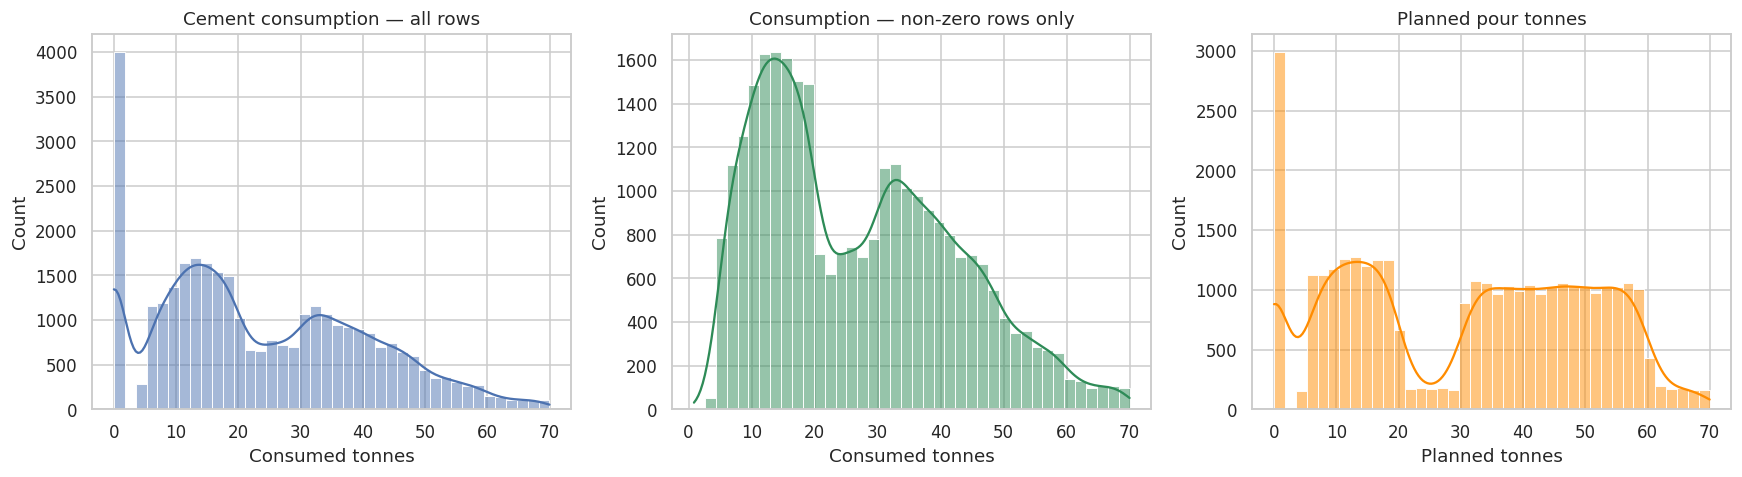

Zero rows          : 4,003 (12.17%)
Non-zero mean      : 27.01 t   median: 24.64 t
Non-zero skew      : 0.524   (near-symmetric — no log transform needed)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(panel["consumed_tonnes"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Cement consumption — all rows")
axes[0].set_xlabel("Consumed tonnes")

sns.histplot(panel.loc[panel["consumed_tonnes"] > 0, "consumed_tonnes"],
             bins=40, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("Consumption — non-zero rows only")
axes[1].set_xlabel("Consumed tonnes")

sns.histplot(panel["planned_pour_tonnes"], bins=40, kde=True, color="darkorange", ax=axes[2])
axes[2].set_title("Planned pour tonnes")
axes[2].set_xlabel("Planned tonnes")

plt.tight_layout()
save_fig("target_distributions")
plt.show()

nz = panel.loc[panel["consumed_tonnes"] > 0, "consumed_tonnes"]
print(f"Zero rows          : {(panel['consumed_tonnes'] == 0).sum():,} ({(panel['consumed_tonnes'] == 0).mean():.2%})")
print(f"Non-zero mean      : {nz.mean():.2f} t   median: {nz.median():.2f} t")
print(f"Non-zero skew      : {nz.skew():.3f}   (near-symmetric — no log transform needed)")

In [10]:
# ==========================================
# What are the zeros? Decompose them.
# ==========================================
zeros = panel["consumed_tonnes"] == 0

# (a) Is a zero pour scheduled?
no_pour_planned = panel["planned_pour_tonnes"] == 0
print("(a) planned_pour_tonnes == 0")
print(f"    rows                          : {no_pour_planned.sum():,} ({no_pour_planned.mean():.2%} of panel)")
print(f"    of which consumed == 0        : {(panel.loc[no_pour_planned, 'consumed_tonnes'] == 0).mean():.2%}")
print("    => a zero plan DETERMINISTICALLY implies zero consumption.\n")

# (b) The remaining zeros, where work WAS scheduled
unexplained = panel[zeros & ~no_pour_planned]
rained_off = unexplained["rain_mm"] > RAIN_STOPPAGE_MM
stocked_out = unexplained["opening_inventory_tonnes"] < 1.0

print(f"(b) zeros despite a planned pour  : {len(unexplained):,}")
print(f"    rain > {RAIN_STOPPAGE_MM:g} mm                 : {rained_off.mean():.1%}")
print(f"    opening inventory < 1 t       : {stocked_out.mean():.1%}")
print(f"    either cause                  : {(rained_off | stocked_out).mean():.1%}")
print(f"    NEITHER (truly unexplained)   : {(~(rained_off | stocked_out)).sum()} row(s)")

(a) planned_pour_tonnes == 0
    rows                          : 2,993 (9.10% of panel)
    of which consumed == 0        : 100.00%
    => a zero plan DETERMINISTICALLY implies zero consumption.

(b) zeros despite a planned pour  : 1,010
    rain > 15 mm                 : 95.3%
    opening inventory < 1 t       : 40.8%
    either cause                  : 99.9%
    NEITHER (truly unexplained)   : 1 row(s)


,rows,% of zeros
No pour scheduled,2993,74.800
Rained off,963,24.100
Stocked out,46,1.100
Unexplained,1,0.000


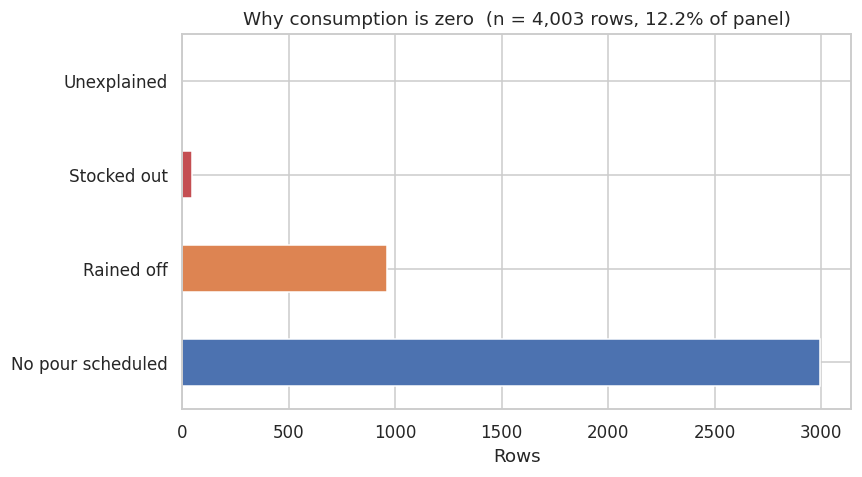

In [11]:
# ==========================================
# Zero-consumption taxonomy
# ==========================================
def classify_zero(row):
    if row["planned_pour_tonnes"] == 0:
        return "No pour scheduled"
    if row["rain_mm"] > RAIN_STOPPAGE_MM:
        return "Rained off"
    if row["opening_inventory_tonnes"] < 1.0:
        return "Stocked out"
    return "Unexplained"

zero_taxonomy = panel[zeros].apply(classify_zero, axis=1).value_counts()
zero_taxonomy_pct = (100 * zero_taxonomy / zero_taxonomy.sum()).round(1)

display(pd.DataFrame({"rows": zero_taxonomy, "% of zeros": zero_taxonomy_pct}))

plt.figure(figsize=(8, 4.5))
zero_taxonomy.plot(kind="barh", color=["#4c72b0", "#dd8452", "#c44e52", "#8172b3"])
plt.title(f"Why consumption is zero  (n = {zeros.sum():,} rows, 12.2% of panel)")
plt.xlabel("Rows")
plt.tight_layout()
save_fig("zero_taxonomy")
plt.show()

**Finding — the zeros are structural, not noise.** Of 4,003 zero-consumption
site-days, 4,002 are fully explained by three causes, all of which are knowable
or forecastable ahead of time:

1. **No pour scheduled** (2,993 rows, 74.8% of zeros). `planned_pour_tonnes == 0`
   implies `consumed_tonnes == 0` on **100%** of rows. This is deterministic.
2. **Rained off** (963 rows, 95.3% of the remaining zeros) — see §9.
3. **Stocked out** (46 rows) — no opening inventory.

Exactly **one** row out of 32,880 is unexplained.

**Consequences.** Do not treat zero-inflation as a nuisance to be smoothed. A
two-stage (hurdle) structure is the honest specification: stage 1 predicts
*whether* a pour happens — and it is close to a lookup, not a learned model —
and stage 2 predicts *how much*, conditional on it happening. Reporting MAPE
across these rows was never going to work, which is the empirical backing for
the WAPE/MASE renegotiation in WORKFLOW §1.3(e).

## 6 — Temporal structure and seasonality

WORKFLOW §1.3(d) claims there is almost no calendar seasonality. This section
tests that formally and, importantly, quantifies the *effect size* — a
statistically detectable seasonal term that moves demand by 3% is not a
modelling asset.

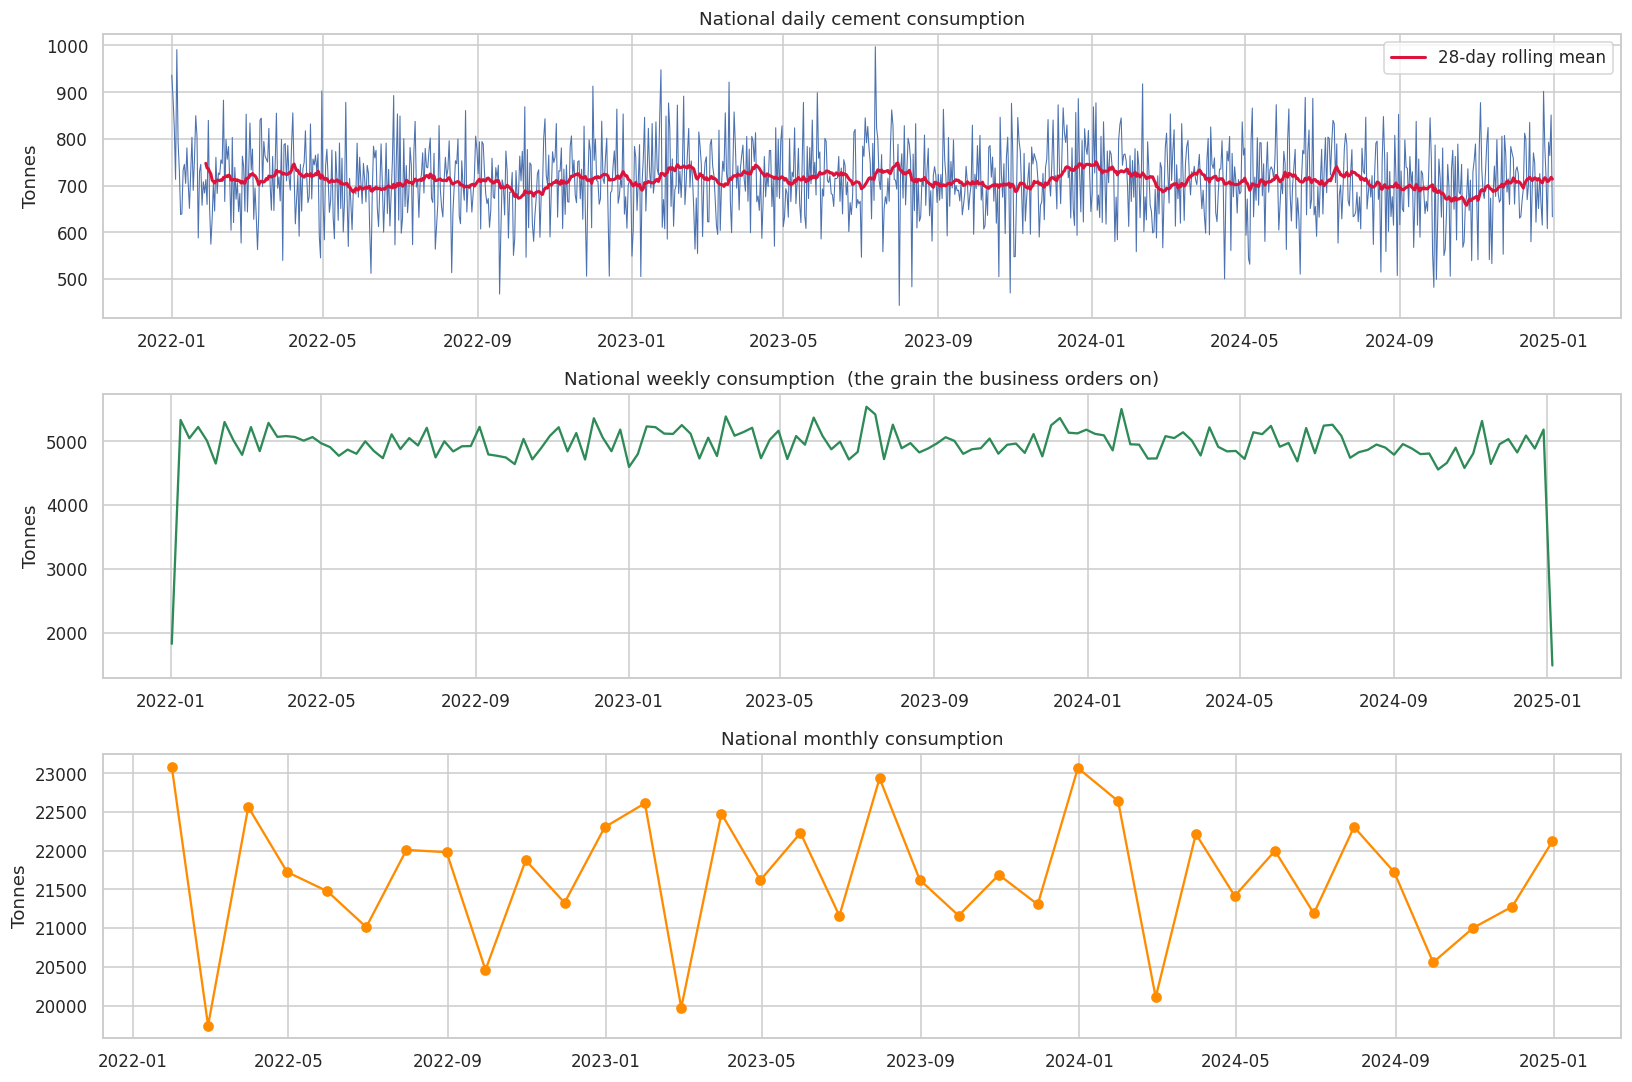

In [12]:
national_daily = panel.groupby("date")["consumed_tonnes"].sum().asfreq("D")
national_weekly = national_daily.resample("W").sum()
national_monthly = national_daily.resample("ME").sum()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

axes[0].plot(national_daily.index, national_daily.values, linewidth=0.7)
axes[0].plot(national_daily.index, national_daily.rolling(28).mean(),
             color="crimson", linewidth=2, label="28-day rolling mean")
axes[0].set_title("National daily cement consumption")
axes[0].set_ylabel("Tonnes")
axes[0].legend()

axes[1].plot(national_weekly.index, national_weekly.values, color="seagreen")
axes[1].set_title("National weekly consumption  (the grain the business orders on)")
axes[1].set_ylabel("Tonnes")

axes[2].plot(national_monthly.index, national_monthly.values, marker="o", color="darkorange")
axes[2].set_title("National monthly consumption")
axes[2].set_ylabel("Tonnes")

plt.tight_layout()
save_fig("temporal_trend")
plt.show()

Grand mean consumption : 23.72 t / site-day

Weekday peak-to-trough : 0.67 t  (2.8% of the mean)
Monthly peak-to-trough : 1.46 t  (6.2% of the mean)  (high 1, low 9)
Yearly peak-to-trough  : 0.37 t  (1.5% of the mean)


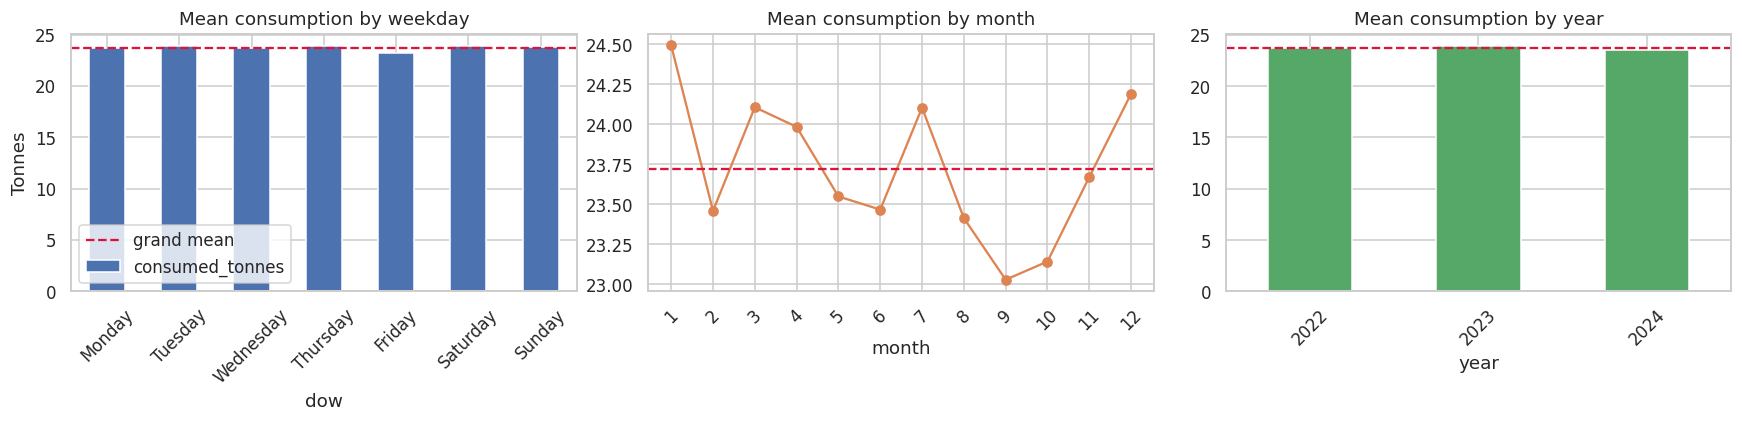

In [13]:
# ==========================================
# Seasonality effect sizes
# ==========================================
panel["dow"] = panel["date"].dt.day_name()
panel["month"] = panel["date"].dt.month
panel["year"] = panel["date"].dt.year

grand_mean = panel["consumed_tonnes"].mean()
dow_mean = panel.groupby("dow")["consumed_tonnes"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
month_mean = panel.groupby("month")["consumed_tonnes"].mean()
year_mean = panel.groupby("year")["consumed_tonnes"].mean()

def spread(s):
    return f"{s.max() - s.min():.2f} t  ({100 * (s.max() - s.min()) / grand_mean:.1f}% of the mean)"

print(f"Grand mean consumption : {grand_mean:.2f} t / site-day\n")
print(f"Weekday peak-to-trough : {spread(dow_mean)}")
print(f"Monthly peak-to-trough : {spread(month_mean)}  (high {month_mean.idxmax()}, low {month_mean.idxmin()})")
print(f"Yearly peak-to-trough  : {spread(year_mean)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
dow_mean.plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Mean consumption by weekday"); axes[0].set_ylabel("Tonnes")
axes[0].axhline(grand_mean, color="crimson", linestyle="--", label="grand mean"); axes[0].legend()

month_mean.plot(marker="o", ax=axes[1], color="#dd8452")
axes[1].set_title("Mean consumption by month"); axes[1].set_xticks(range(1, 13))
axes[1].axhline(grand_mean, color="crimson", linestyle="--")

year_mean.plot(kind="bar", ax=axes[2], color="#55a868")
axes[2].set_title("Mean consumption by year")
axes[2].axhline(grand_mean, color="crimson", linestyle="--")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
save_fig("seasonality_effect_sizes")
plt.show()

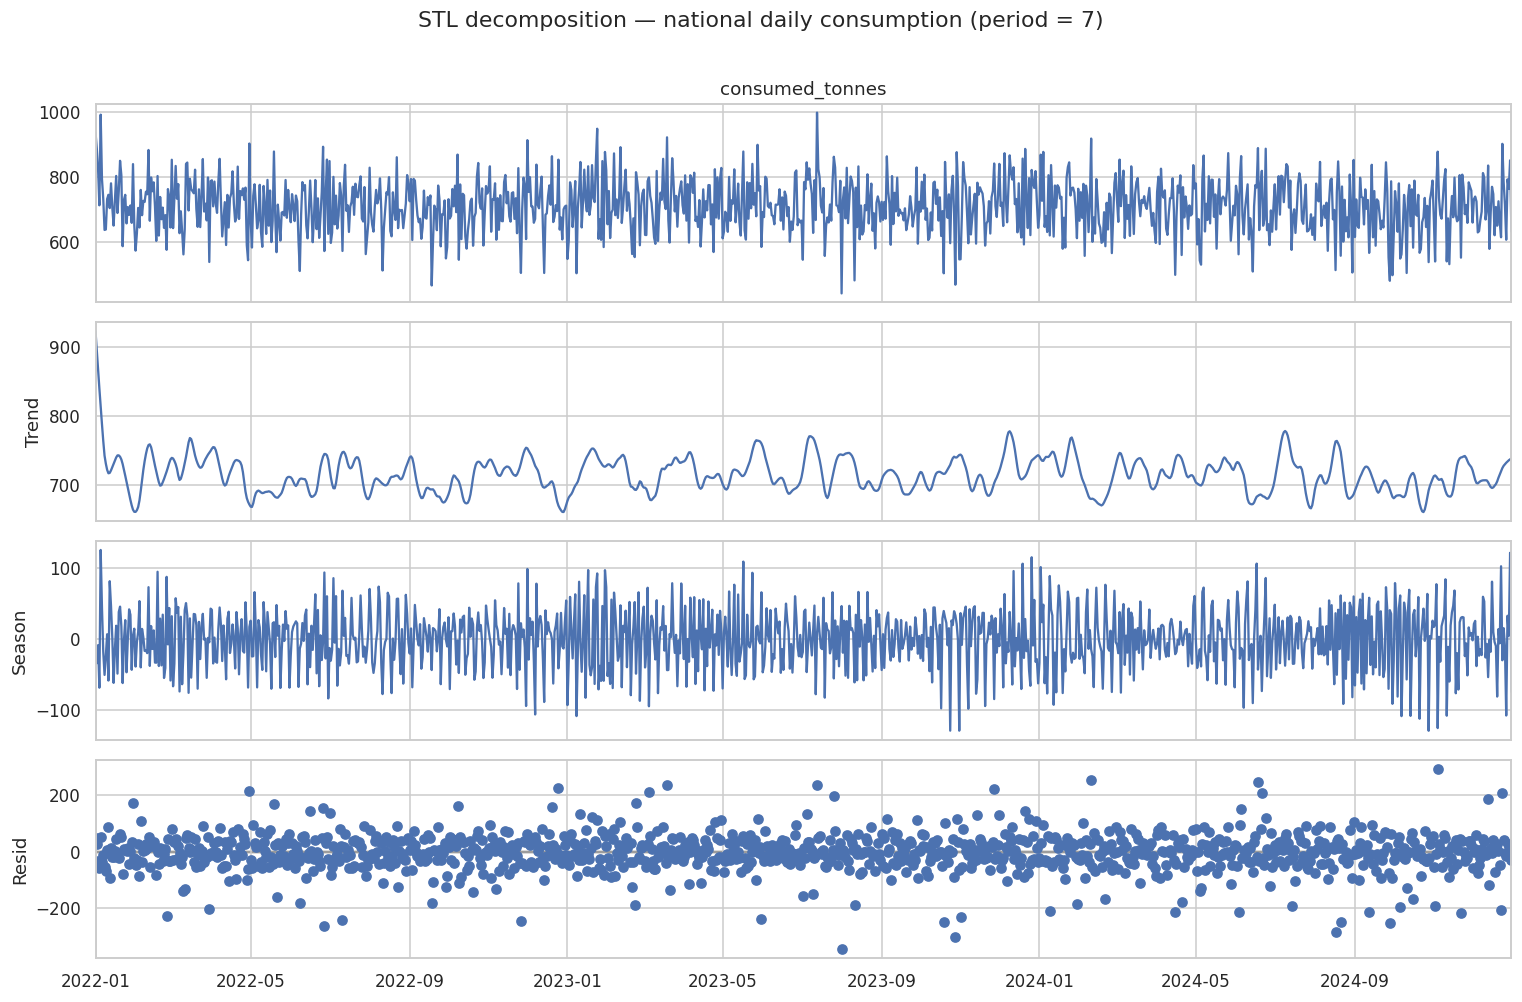

Variance share — trend    : 9.70%
Variance share — seasonal : 25.41%
Variance share — residual : 64.89%

Seasonal strength max(0, 1 - Var(resid)/Var(seasonal+resid)) = 0.281


In [14]:
# ==========================================
# Formal decomposition (STL, weekly period on the national daily series)
# ==========================================
stl = STL(national_daily, period=7, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(14, 9)
plt.suptitle("STL decomposition — national daily consumption (period = 7)", y=1.01)
plt.tight_layout()
save_fig("stl_decomposition")
plt.show()

var_seasonal = np.var(stl.seasonal)
var_resid = np.var(stl.resid)
var_trend = np.var(stl.trend)
total = var_seasonal + var_resid + var_trend

print(f"Variance share — trend    : {var_trend / total:.2%}")
print(f"Variance share — seasonal : {var_seasonal / total:.2%}")
print(f"Variance share — residual : {var_resid / total:.2%}")
print(f"\nSeasonal strength max(0, 1 - Var(resid)/Var(seasonal+resid)) = "
      f"{max(0, 1 - var_resid / (var_seasonal + var_resid)):.3f}")

**Finding — there is no *usable* calendar seasonality.** Weekday peak-to-trough
is 0.67 t (2.8% of the mean), monthly 1.46 t (6.2%), annual 0.37 t (1.5%).

The STL output needs care, because read carelessly it says the opposite. STL
assigns 25.4% of variance to its seasonal component — but seasonal *strength* is
only 0.281 (conventionally, below ~0.6 is weak), and STL's seasonal component is
permitted to evolve over time, so on a near-white-noise series it absorbs
short-run wiggle rather than a repeating cycle. The decisive number is in §8: a
**fixed** weekday effect explains 0.0% of panel variance and a fixed month effect
0.1%. A component that cannot be pinned to a repeating calendar position is not
something a forecast can use.

This is not a failure to detect a signal; it is the absence of one. The
construction schedule in this data does not follow the calendar.

**Consequences.** SARIMA/SARIMAX *seasonal* terms will contribute nothing —
budget no time to tuning `(P, D, Q, s)`. Calendar features (month, weekday,
week-of-year) are near-worthless as predictors and should be dropped rather than
carried through Phase 3 as noise. Keep SARIMA**X** on the shortlist only for its
exogenous regressors, and expect it to be beaten.

## 7 — Autocorrelation (WORKFLOW §2.2)

The planned feature set in WORKFLOW §2.5 leads with lags (1, 7, 14, 28) and
rolling means. Those features are only worth building if the series has memory.
This section tests that before notebook 03 spends effort on it.

In [15]:
# ==========================================
# Site-level autocorrelation — the modelling grain
# ==========================================
site_series = panel.sort_values(["site_id", "date"]).groupby("site_id")["consumed_tonnes"]
LAGS = [1, 2, 3, 7, 14, 21, 28]

acf_by_site = pd.DataFrame(
    {lag: site_series.apply(lambda s, l=lag: s.autocorr(l)) for lag in LAGS}
)

acf_summary = pd.DataFrame({
    "mean": acf_by_site.mean(),
    "min across sites": acf_by_site.min(),
    "max across sites": acf_by_site.max(),
    "sites |r| > 0.10": (acf_by_site.abs() > 0.10).sum(),
}).round(4)
acf_summary.index.name = "lag (days)"
display(acf_summary)

print(f"Approx 95% white-noise band for a single site series: +/- {1.96 / np.sqrt(1096):.3f}")
print("\nThe mean is near zero AND no individual site exceeds |r| = 0.10 at any lag,")
print("so this is not sign-cancellation across sites — the memory genuinely is absent.")

,mean,min across sites,max across sites,sites |r| > 0.10
lag (days),,,,
1,-0.015,-0.066,0.055,0
2,-0.013,-0.080,0.058,0
3,-0.014,-0.072,0.059,0
7,-0.001,-0.078,0.088,0
14,0.004,-0.045,0.065,0
21,0.005,-0.080,0.058,0
28,0.008,-0.054,0.061,0


Approx 95% white-noise band for a single site series: +/- 0.059

The mean is near zero AND no individual site exceeds |r| = 0.10 at any lag,
so this is not sign-cancellation across sites — the memory genuinely is absent.


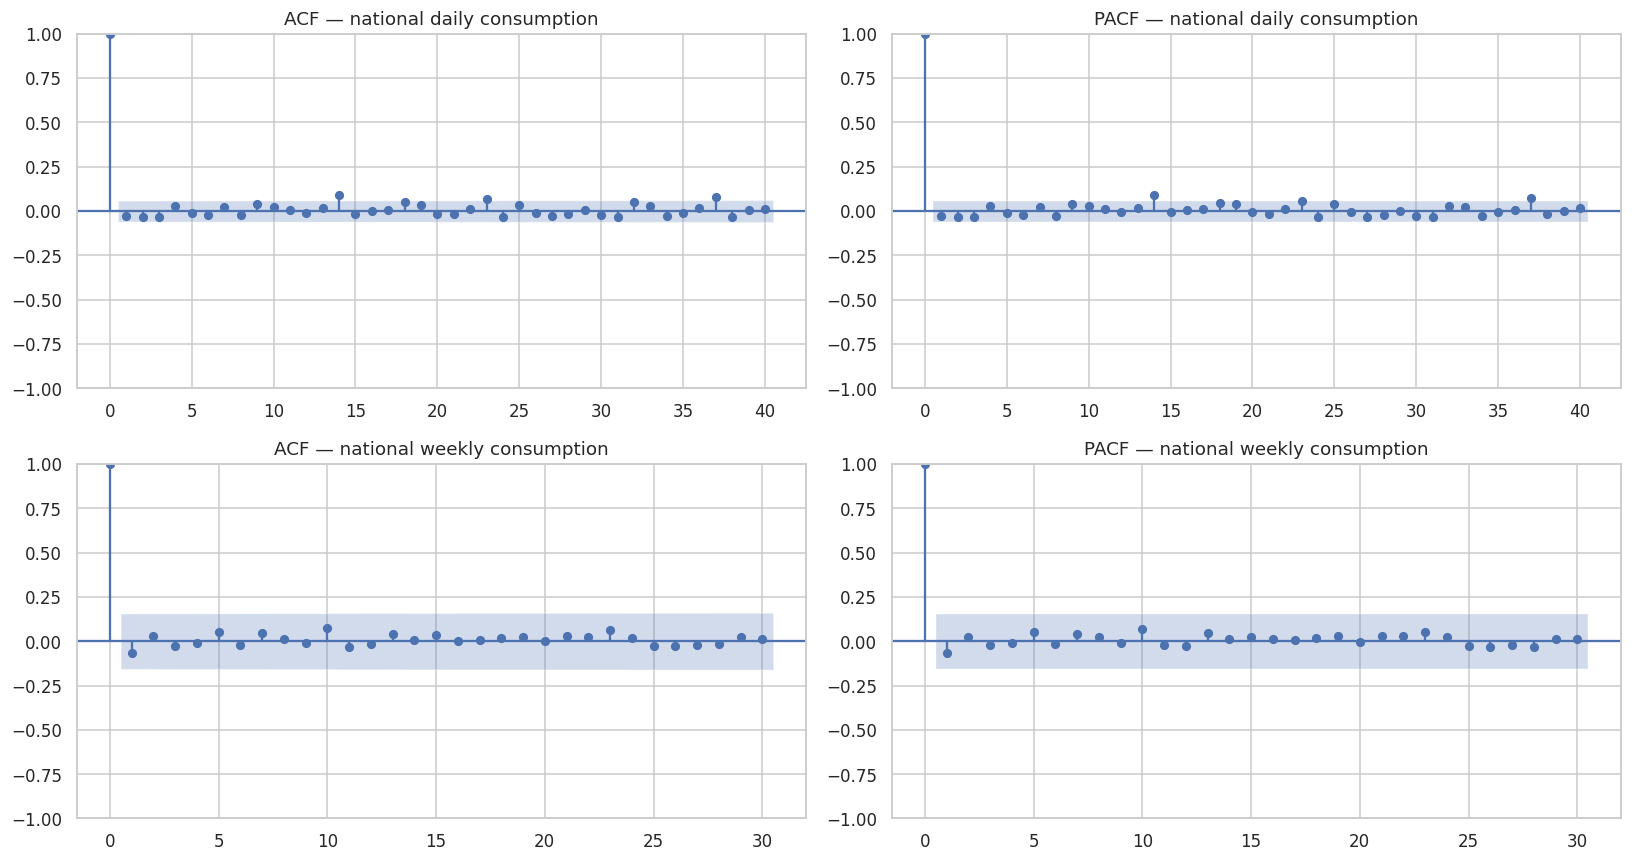

National daily  lag-1 autocorr: -0.030
National daily  lag-7 autocorr: +0.024
National weekly lag-1 autocorr: -0.109


In [16]:
# ==========================================
# ACF / PACF at national grain, daily and weekly
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_acf(national_daily, lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF — national daily consumption")
plot_pacf(national_daily, lags=40, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — national daily consumption")

plot_acf(national_weekly, lags=30, ax=axes[1, 0])
axes[1, 0].set_title("ACF — national weekly consumption")
plot_pacf(national_weekly, lags=30, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — national weekly consumption")

plt.tight_layout()
save_fig("acf_pacf")
plt.show()

print(f"National daily  lag-1 autocorr: {national_daily.autocorr(1):+.3f}")
print(f"National daily  lag-7 autocorr: {national_daily.autocorr(7):+.3f}")
print(f"National weekly lag-1 autocorr: {national_weekly.autocorr(1):+.3f}")

In [17]:
# ==========================================
# Does the EXOGENOUS driver have the memory instead?
# ==========================================
# If planned pour is autocorrelated, lagged *planned pour* is a useful feature
# even though lagged consumption is not.
planned_series = panel.sort_values(["site_id", "date"]).groupby("site_id")["planned_pour_tonnes"]
planned_acf = pd.Series(
    {lag: planned_series.apply(lambda s, l=lag: s.autocorr(l)).mean() for lag in LAGS},
    name="mean site autocorr",
).round(4)
planned_acf.index.name = "lag (days)"

comparison = pd.concat(
    [acf_by_site.mean().rename("consumed_tonnes"), planned_acf.rename("planned_pour_tonnes")],
    axis=1,
).round(4)
display(comparison)

,consumed_tonnes,planned_pour_tonnes
lag (days),,
1,-0.015,0.001
2,-0.013,0.001
3,-0.014,0.003
7,-0.001,-0.005
14,0.004,0.005
21,0.005,0.003
28,0.008,0.002


**Finding — the series has no temporal memory at any grain.** Mean site-level
autocorrelation is −0.015 at lag 1, −0.001 at lag 7, 0.004 at lag 14 and 0.008 at
lag 28. Critically, **no individual site exceeds |r| = 0.10 at any lag**, so this
is not an averaging artefact. The national daily and weekly ACF/PACF sit inside
the white-noise band throughout. `planned_pour_tonnes` is equally memoryless.

**Consequences — this changes the Phase 2 and Phase 3 plans.**

- The lag and rolling-statistic block in WORKFLOW §2.5 should be **cut**, not
  built. Lagged target values carry no information here and each one costs a row
  of warm-up, adds leakage surface, and dilutes tree splits.
- Classical ARIMA-family models have nothing to work with: with no AR or MA
  structure and no seasonality, SARIMAX collapses to an OLS on the exogenous
  regressors. Fit it once as a documented baseline; do not script 30 per-site fits.
- The predictive signal is entirely **contemporaneous and exogenous**. Phase 3
  should be framed as a supervised regression on same-period drivers, which is
  what §13 confirms.
- Keep this result in `REPORTS/decisions.md` — it is the justification for a
  feature set that will look surprisingly thin to a reviewer expecting a
  time-series project.

## 8 — Cross-sectional heterogeneity (WORKFLOW §2.1)

The question is not "do sites differ" — they will. It is whether they differ
enough, and along which dimension, to justify 30 per-site models over one pooled
global model. A variance decomposition answers that; a bar chart does not.

,region,behavior,silo_capacity,mean_consumed,std_consumed,mean_planned,pct_constrained,mean_utilisation,cv,fill_rate
site_id,,,,,,,,,,
SITE_025,South,aggressive,261,30.660,15.180,42.720,63.690,0.050,0.500,71.800
SITE_010,West,aggressive,158,30.640,14.890,42.810,63.500,0.080,0.490,71.600
SITE_018,East,aggressive,152,30.430,14.280,42.730,63.780,0.090,0.470,71.200
SITE_001,North,aggressive,448,30.160,14.900,42.580,64.230,0.030,0.490,70.800
SITE_021,East,aggressive,180,30.120,14.500,43.220,66.610,0.060,0.480,69.700
SITE_005,South,aggressive,230,30.050,14.610,42.320,64.690,0.050,0.490,71.000
SITE_022,South,aggressive,487,30.050,14.390,43.200,66.330,0.030,0.480,69.600
SITE_008,West,aggressive,260,29.830,14.460,43.010,67.340,0.050,0.480,69.300
SITE_007,East,aggressive,485,29.750,14.520,43.020,64.690,0.030,0.490,69.200


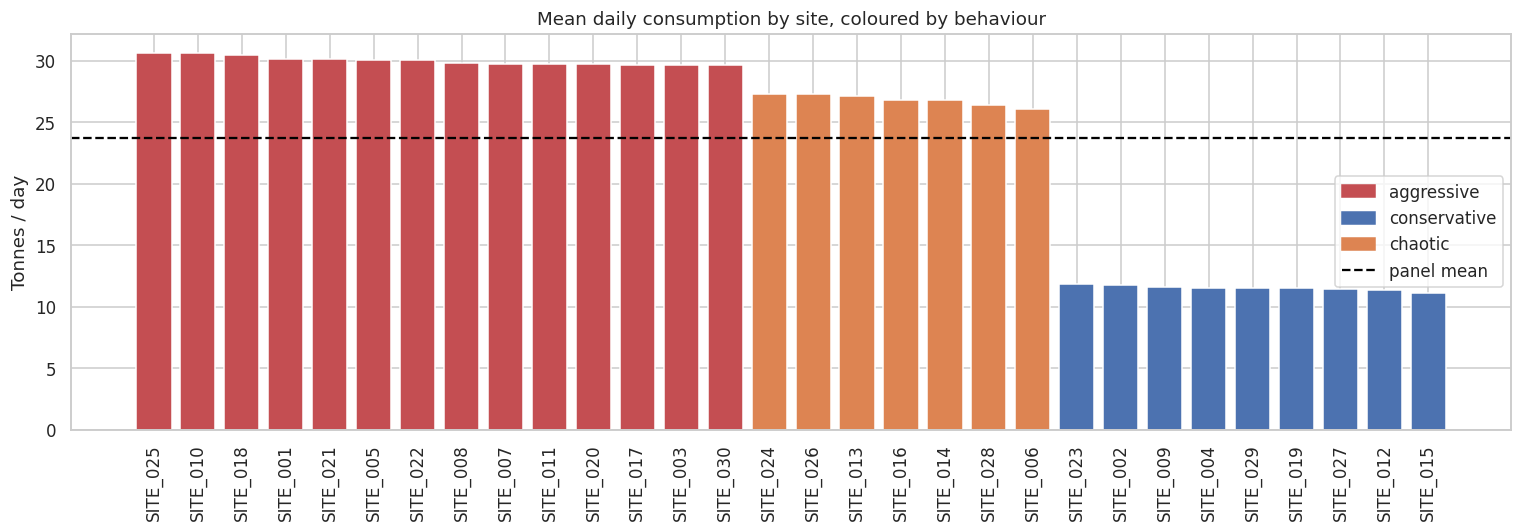

In [18]:
# ==========================================
# Site-level demand profile
# ==========================================
site_profile = (
    panel.groupby("site_id")
    .agg(
        region=("region", "first"),
        behavior=("behavior", "first"),
        silo_capacity=("silo_capacity", "first"),
        mean_consumed=("consumed_tonnes", "mean"),
        std_consumed=("consumed_tonnes", "std"),
        mean_planned=("planned_pour_tonnes", "mean"),
        pct_constrained=("was_constrained", lambda s: 100 * s.mean()),
        mean_utilisation=("silo_utilisation", "mean"),
    )
    .sort_values("mean_consumed", ascending=False)
)
site_profile["cv"] = (site_profile["std_consumed"] / site_profile["mean_consumed"]).round(3)
site_profile["fill_rate"] = (100 * site_profile["mean_consumed"] / site_profile["mean_planned"]).round(1)
display(site_profile.round(2))

plt.figure(figsize=(14, 5))
colours = {"aggressive": "#c44e52", "conservative": "#4c72b0", "chaotic": "#dd8452"}
plt.bar(site_profile.index, site_profile["mean_consumed"],
        color=[colours[b] for b in site_profile["behavior"]])
plt.axhline(panel["consumed_tonnes"].mean(), color="black", linestyle="--", label="panel mean")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colours.values()]
plt.legend(handles + [plt.Line2D([0], [0], color="black", linestyle="--")],
           list(colours.keys()) + ["panel mean"])
plt.title("Mean daily consumption by site, coloured by behaviour")
plt.ylabel("Tonnes / day")
plt.xticks(rotation=90)
plt.tight_layout()
save_fig("site_heterogeneity")
plt.show()

,groups,between-group variance share
grouping,,
site_id,30,0.231
behavior,3,0.230
region,4,0.015
cement_type,3,0.000
dow,7,0.000
month,12,0.001


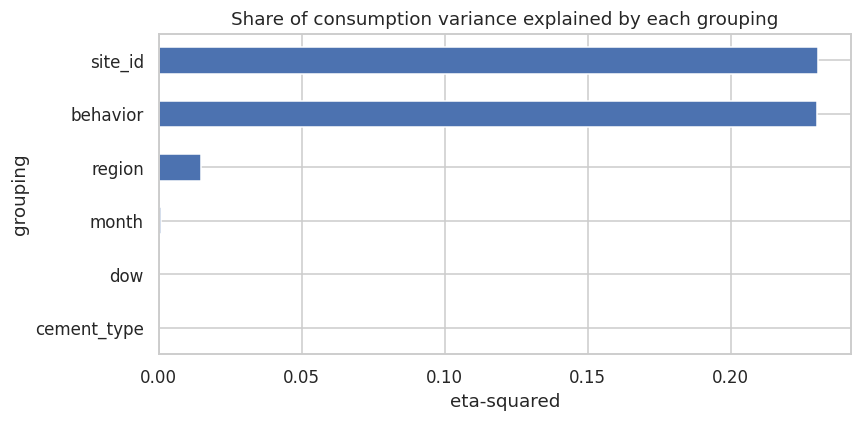

In [19]:
# ==========================================
# Variance decomposition — what actually separates sites?
# ==========================================
# Between-group share = SS_between / SS_total (eta-squared).
grand = panel["consumed_tonnes"].mean()
ss_total = ((panel["consumed_tonnes"] - grand) ** 2).sum()

rows = []
for key in ["site_id", "behavior", "region", "cement_type", "dow", "month"]:
    group_mean = panel.groupby(key)["consumed_tonnes"].transform("mean")
    ss_between = ((group_mean - grand) ** 2).sum()
    rows.append({
        "grouping": key,
        "groups": panel[key].nunique(),
        "between-group variance share": ss_between / ss_total,
    })

decomp = pd.DataFrame(rows).set_index("grouping")
decomp["between-group variance share"] = decomp["between-group variance share"].round(4)
display(decomp)

plt.figure(figsize=(8, 4))
decomp["between-group variance share"].sort_values().plot(kind="barh", color="#4c72b0")
plt.title("Share of consumption variance explained by each grouping")
plt.xlabel("eta-squared")
plt.tight_layout()
save_fig("variance_decomposition")
plt.show()

In [20]:
# ==========================================
# Is the site effect just the behaviour effect?
# ==========================================
# If conditioning on behaviour first leaves little residual site variance, then
# behaviour (a 3-level static attribute) is sufficient and 30 models are waste.
resid_after_behavior = panel["consumed_tonnes"] - panel.groupby("behavior")["consumed_tonnes"].transform("mean")
grand_r = resid_after_behavior.mean()
ss_total_r = ((resid_after_behavior - grand_r) ** 2).sum()
site_mean_r = resid_after_behavior.groupby(panel["site_id"]).transform("mean")
ss_between_r = ((site_mean_r - grand_r) ** 2).sum()

site_share = decomp.loc["site_id", "between-group variance share"]
behav_share = decomp.loc["behavior", "between-group variance share"]

print(f"Site variance share, unconditional            : {site_share:.2%}")
print(f"Behaviour variance share, unconditional       : {behav_share:.2%}")
print(f"Site variance share, AFTER removing behaviour : {ss_between_r / ss_total_r:.2%}")
print("\n=> behaviour absorbs essentially all of the site effect.\n")

# Why do the groups differ? Throughput, against near-identical silos.
profile = panel.groupby("behavior").agg(
    sites=("site_id", "nunique"),
    mean_silo_capacity=("silo_capacity", "mean"),
    mean_planned=("planned_pour_tonnes", "mean"),
    mean_consumed=("consumed_tonnes", "mean"),
)
profile["silo cover at plan (days)"] = profile["mean_silo_capacity"] / profile["mean_planned"]
display(profile.round(2))

Site variance share, unconditional            : 23.06%
Behaviour variance share, unconditional       : 23.02%
Site variance share, AFTER removing behaviour : 0.05%

=> behaviour absorbs essentially all of the site effect.



,sites,mean_silo_capacity,mean_planned,mean_consumed,silo cover at plan (days)
behavior,,,,,
aggressive,14,305.860,42.740,30.010,7.160
chaotic,7,338.290,30.820,26.820,10.980
conservative,9,319.560,11.880,11.520,26.900


,sites,total_tonnes,mean_per_site_day
region,,,
West,4,"108,221.080",24.690
South,11,"294,887.830",24.460
East,12,"318,968.120",24.250
North,3,"57,852.180",17.590


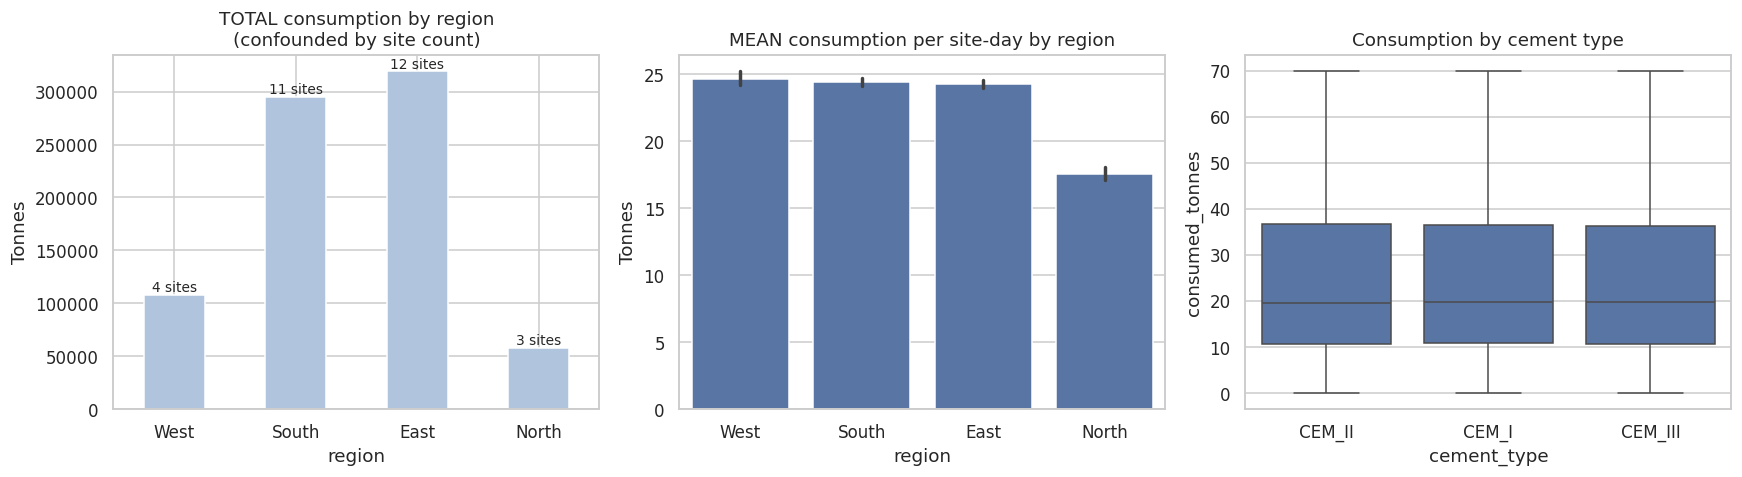

In [21]:
# ==========================================
# Region and cement type
# ==========================================
# Totals by region are dominated by SITE COUNT, not by site-level demand.
region_summary = (
    panel.groupby("region")
    .agg(
        sites=("site_id", "nunique"),
        total_tonnes=("consumed_tonnes", "sum"),
        mean_per_site_day=("consumed_tonnes", "mean"),
    )
    .sort_values("mean_per_site_day", ascending=False)
)
display(region_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

region_summary["total_tonnes"].plot(kind="bar", ax=axes[0], color="lightsteelblue")
for i, (tot, n) in enumerate(zip(region_summary["total_tonnes"], region_summary["sites"])):
    axes[0].text(i, tot, f"{n} sites", ha="center", va="bottom", fontsize=9)
axes[0].set_title("TOTAL consumption by region\n(confounded by site count)")
axes[0].set_ylabel("Tonnes")

sns.barplot(data=panel, x="region", y="consumed_tonnes", estimator="mean",
            errorbar=("ci", 95), order=region_summary.index, ax=axes[1])
axes[1].set_title("MEAN consumption per site-day by region")
axes[1].set_ylabel("Tonnes")

sns.boxplot(data=panel, x="cement_type", y="consumed_tonnes", ax=axes[2])
axes[2].set_title("Consumption by cement type")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_fig("region_and_type")
plt.show()

**Finding — heterogeneity is real but it is *behavioural*, not geographic.**

| grouping | groups | variance share |
|---|---|---|
| `site_id` | 30 | **23.1%** |
| `behavior` | 3 | **23.0%** |
| `region` | 4 | 1.5% |
| `cement_type` | 3 | 0.0% |
| `dow` / `month` | 7 / 12 | ~0% |

`behavior` — a three-level static attribute — captures essentially all of the
site-level variance that 30 separate site dummies capture. After removing the
behaviour means, the residual between-site variance share is **0.05%**. The
30-site bar chart is really a three-group chart: aggressive sites cluster at
~30 t/day, chaotic at ~26.8, conservative at ~11.5, with almost no spread inside
a group.

**What the groups actually are.** Silo capacities are statistically identical
across the three (mean 306 / 338 / 320 t, same 120–487 t range), but planned
throughput is not: 42.7 t/day for aggressive sites against 11.9 for conservative.
So aggressive sites hold only **7.2 days** of silo cover at plan versus **26.9**
for conservative. "Behaviour" is therefore a throughput-to-storage ratio, not a
management style — which is why it predicts both demand level and, in §10, the
censoring rate.

**Consequences.**

- **Build one global pooled model**, with `behavior` as a categorical feature.
  Thirty per-site models would fit the same structure with 1/30th of the data
  each. This settles WORKFLOW §2.1.
- **`region` is close to useless** (1.5%) and its apparent importance in a naive
  chart is an artefact: East has 12 sites and North has 3, so *total* consumption
  ranks regions by headcount. On a per-site-day basis West (24.7 t) edges out
  South (24.5 t) and East (24.3 t); only North (17.6 t) genuinely differs.
- **`cement_type` explains 0.0% of variance.** It is an inventory-grade label,
  not a demand driver. Carry it for reporting and silo allocation; do not expect
  it to earn its place as a predictor.

## 9 — Weather: threshold, not gradient (WORKFLOW §2.3)

The pooled correlation between rain and consumption is r = −0.18, which reads as
"a mild linear drag". WORKFLOW §2.3 asks whether the effect is instead
threshold-like — pours cancelled above some rainfall level. That is a different
functional form and demands a different feature.

In [22]:
# ==========================================
# Fine-grained rainfall profile
# ==========================================
rain_bins = [0, 2, 5, 8, 10, 12, 14, 15, 16, 20, 50]
panel["rain_band"] = pd.cut(panel["rain_mm"], bins=rain_bins, include_lowest=True)

rain_profile = (
    panel.groupby("rain_band", observed=False)
    .agg(
        rows=("consumed_tonnes", "size"),
        mean_planned=("planned_pour_tonnes", "mean"),
        mean_consumed=("consumed_tonnes", "mean"),
        pct_zero_days=("consumed_tonnes", lambda s: 100 * (s == 0).mean()),
        fill_rate_pct=("consumed_tonnes", "sum"),
    )
)
rain_profile["fill_rate_pct"] = (
    100 * panel.groupby("rain_band", observed=False)["consumed_tonnes"].sum()
    / panel.groupby("rain_band", observed=False)["planned_pour_tonnes"].sum()
)
display(rain_profile.round(2))

,rows,mean_planned,mean_consumed,pct_zero_days,fill_rate_pct
rain_band,,,,,
"(-0.001, 2.0]",10877,30.670,24.680,9.260,80.480
"(2.0, 5.0]",9909,30.570,24.710,9.460,80.830
"(5.0, 8.0]",5362,30.980,24.930,8.910,80.460
"(8.0, 10.0]",2303,30.470,24.500,9.510,80.410
"(10.0, 12.0]",1480,31.110,25.250,9.120,81.170
"(12.0, 14.0]",963,30.610,24.800,9.550,81.010
"(14.0, 15.0]",359,30.900,24.560,8.640,79.480
"(15.0, 16.0]",314,31.490,3.950,68.150,12.540
"(16.0, 20.0]",694,30.140,3.890,68.010,12.920


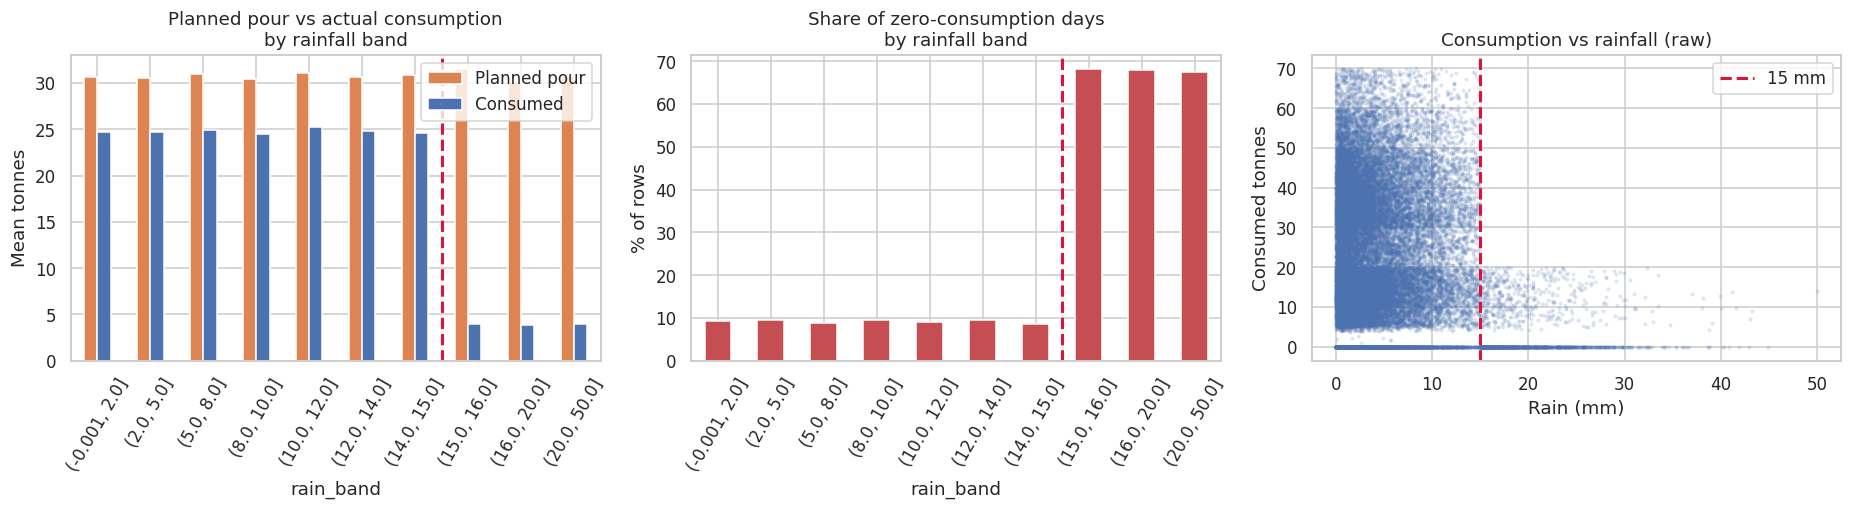

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

rain_profile[["mean_planned", "mean_consumed"]].plot(kind="bar", ax=axes[0],
                                                     color=["#dd8452", "#4c72b0"])
axes[0].set_title("Planned pour vs actual consumption\nby rainfall band")
axes[0].set_ylabel("Mean tonnes")
axes[0].legend(["Planned pour", "Consumed"])

rain_profile["pct_zero_days"].plot(kind="bar", ax=axes[1], color="#c44e52")
axes[1].set_title("Share of zero-consumption days\nby rainfall band")
axes[1].set_ylabel("% of rows")

axes[2].scatter(panel["rain_mm"], panel["consumed_tonnes"], s=3, alpha=0.12)
axes[2].axvline(RAIN_STOPPAGE_MM, color="crimson", linestyle="--", linewidth=2,
                label=f"{RAIN_STOPPAGE_MM:g} mm")
axes[2].set_title("Consumption vs rainfall (raw)")
axes[2].set_xlabel("Rain (mm)")
axes[2].set_ylabel("Consumed tonnes")
axes[2].legend()

for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=60)
    ax.axvline(6.5, color="crimson", linestyle="--", linewidth=2)

plt.tight_layout()
save_fig("rain_threshold")
plt.show()

In [24]:
# ==========================================
# Quantify the break
# ==========================================
above = panel[panel["rain_mm"] > RAIN_STOPPAGE_MM]
below = panel[panel["rain_mm"] <= RAIN_STOPPAGE_MM]

comparison = pd.DataFrame({
    f"rain <= {RAIN_STOPPAGE_MM:g} mm": [
        len(below),
        below["planned_pour_tonnes"].mean(),
        below["consumed_tonnes"].mean(),
        100 * (below["consumed_tonnes"] == 0).mean(),
        below["rain_mm"].corr(below["consumed_tonnes"]),
    ],
    f"rain > {RAIN_STOPPAGE_MM:g} mm": [
        len(above),
        above["planned_pour_tonnes"].mean(),
        above["consumed_tonnes"].mean(),
        100 * (above["consumed_tonnes"] == 0).mean(),
        above["rain_mm"].corr(above["consumed_tonnes"]),
    ],
}, index=["rows", "mean planned (t)", "mean consumed (t)",
          "% zero-consumption days", "corr(rain, consumed) within band"]).round(3)
display(comparison)

print(f"Pooled corr(rain, consumed)            : {panel['rain_mm'].corr(panel['consumed_tonnes']):+.3f}")
print(f"Corr within rain <= {RAIN_STOPPAGE_MM:g} mm            : {below['rain_mm'].corr(below['consumed_tonnes']):+.3f}  <- effectively zero")
print(f"Share of ALL zero rows with rain > {RAIN_STOPPAGE_MM:g}mm: "
      f"{(panel.loc[panel['consumed_tonnes'] == 0, 'rain_mm'] > RAIN_STOPPAGE_MM).mean():.1%}")
print()
print(f"Planned pour is statistically identical either side of the break "
      f"({below['planned_pour_tonnes'].mean():.2f} t vs {above['planned_pour_tonnes'].mean():.2f} t),")
print("so this is CANCELLATION of scheduled work, not lower demand.")

,rain <= 15 mm,rain > 15 mm
rows,"31,253.000","1,627.000"
mean planned (t),30.700,30.645
mean consumed (t),24.750,3.945
% zero-consumption days,9.276,67.855
"corr(rain, consumed) within band",0.005,0.012


Pooled corr(rain, consumed)            : -0.180
Corr within rain <= 15 mm            : +0.005  <- effectively zero
Share of ALL zero rows with rain > 15mm: 27.6%

Planned pour is statistically identical either side of the break (30.70 t vs 30.65 t),
so this is CANCELLATION of scheduled work, not lower demand.


**Finding — rain is a switch at 15.0 mm, not a gradient.**

| | rain ≤ 15 mm | rain > 15 mm |
|---|---|---|
| rows | 31,253 (95.1%) | 1,627 (4.9%) |
| mean **planned** pour | 30.70 t | 30.65 t |
| mean **consumed** | 24.7 t | **4.0 t** |
| zero-consumption days | 9.3% | **67.9%** |
| corr(rain, consumed) *within* band | **+0.005** | ~0 |

Below the threshold, rainfall has **no relationship whatsoever** with
consumption (r = +0.005). The entire pooled r = −0.18 is the threshold leaking
into a linear statistic. Planned pour is unchanged across the break, so this is
work being cancelled, not demand being lower. It accounts for 27.6% of all
zero-consumption rows in the panel.

**Consequences.**

- Add a binary `rain_stoppage = (rain_mm > 15)` feature. §13 shows this single
  flag cuts benchmark WAPE from 29.4% to 24.7% — a 16% relative improvement with
  no model at all.
- **Drop raw `rain_mm` as a linear term.** It is close to pure noise once the
  flag is present, and a linear coefficient on it actively misrepresents the
  physics.
- At inference the flag needs a *rain forecast*, not an observation. An 8-week
  precipitation forecast is barely better than climatology, so the honest
  production framing is a **probability** of stoppage: `E[consumption] =
  planned x P(rain <= 15 mm)`. State this limitation in the report — it caps
  achievable accuracy at long horizons regardless of model choice.
- `avg_temp_c` shows no comparable structure (r = +0.035) and can be dropped.

## 10 — Censored demand: planned vs actual (WORKFLOW §2.4)

39.7% of site-days consumed less than was planned. `consumed_tonnes` is
therefore *observed* demand, not *true* demand. This section quantifies the gap
and identifies what drives it, because that determines which target Phase 3
should fit.

,sites,rows,% rows constrained,planned (t),consumed (t),unmet (t),fill rate %,mean silo utilisation %
behavior,,,,,,,,
aggressive,14.000,"15,344.000",65.010,"655,736.130","460,446.940","195,289.190",70.220,4.990
chaotic,7.000,"7,672.000",21.770,"236,428.500","205,800.440","30,628.060",87.050,33.660
conservative,9.000,"9,864.000",14.250,"117,157.940","113,681.830","3,476.110",97.030,94.980


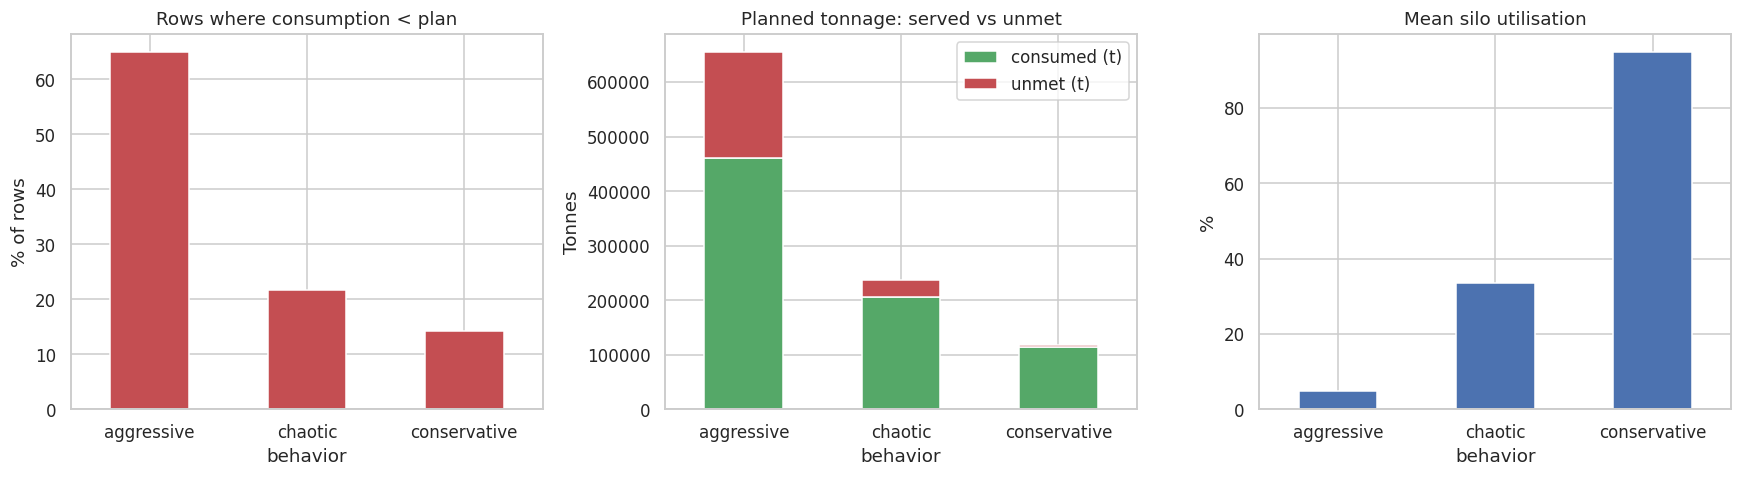

In [25]:
# ==========================================
# Censoring by site behaviour
# ==========================================
censoring = panel.groupby("behavior").apply(
    lambda g: pd.Series({
        "sites": g["site_id"].nunique(),
        "rows": len(g),
        "% rows constrained": 100 * g["was_constrained"].mean(),
        "planned (t)": g["planned_pour_tonnes"].sum(),
        "consumed (t)": g["consumed_tonnes"].sum(),
        "unmet (t)": g["unmet_tonnes"].sum(),
        "fill rate %": 100 * g["consumed_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
        "mean silo utilisation %": 100 * g["silo_utilisation"].mean(),
    }),
    include_groups=False,
).round(2)
display(censoring)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

censoring["% rows constrained"].plot(kind="bar", ax=axes[0], color="#c44e52")
axes[0].set_title("Rows where consumption < plan")
axes[0].set_ylabel("% of rows")

censoring[["consumed (t)", "unmet (t)"]].plot(kind="bar", stacked=True, ax=axes[1],
                                              color=["#55a868", "#c44e52"])
axes[1].set_title("Planned tonnage: served vs unmet")
axes[1].set_ylabel("Tonnes")

censoring["mean silo utilisation %"].plot(kind="bar", ax=axes[2], color="#4c72b0")
axes[2].set_title("Mean silo utilisation")
axes[2].set_ylabel("%")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_fig("censoring_by_behavior")
plt.show()

,rows,% constrained,fill rate %,mean unmet (t)
cover_band,,,,
"(-0.001, 0.25]","10,675.000",82.820,61.880,17.230
"(0.25, 0.5]","1,851.000",56.620,81.580,8.370
"(0.5, 0.75]","1,312.000",33.160,90.090,4.560
"(0.75, 1.0]","1,072.000",21.270,92.260,3.490
"(1.0, 2.0]","2,213.000",19.700,92.200,3.410
"(2.0, 5.0]","2,017.000",19.390,92.240,3.190
"(5.0, inf]","10,747.000",15.560,95.920,0.590


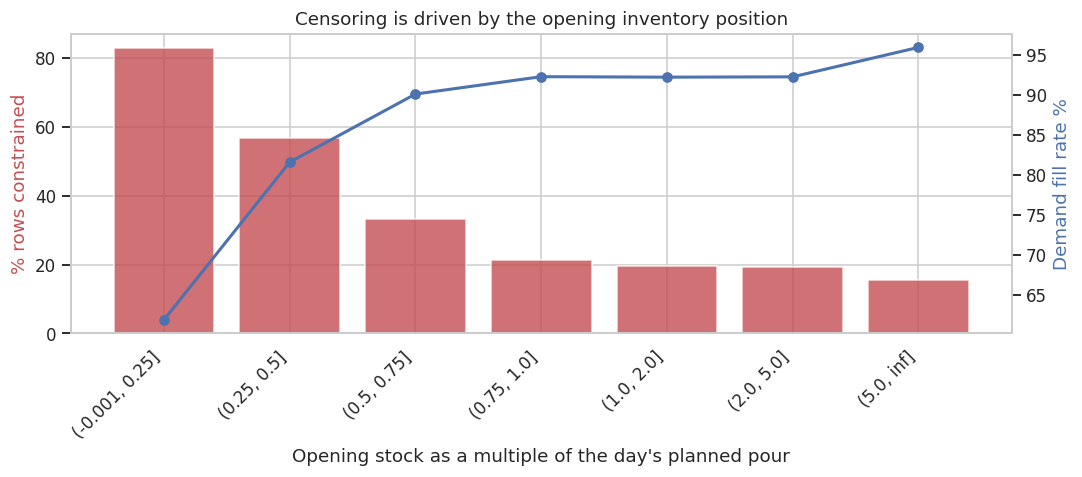

In [26]:
# ==========================================
# Censoring by inventory position at the start of the day
# ==========================================
# Opening cover = opening stock as a multiple of the day's planned pour.
panel["opening_cover"] = np.where(
    panel["planned_pour_tonnes"] > 0,
    panel["opening_inventory_tonnes"] / panel["planned_pour_tonnes"],
    np.nan,
)

cover_bins = [0, 0.25, 0.5, 0.75, 1.0, 2.0, 5.0, np.inf]
panel["cover_band"] = pd.cut(panel["opening_cover"], bins=cover_bins, include_lowest=True)

cover_profile = panel.groupby("cover_band", observed=False).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "% constrained": 100 * g["was_constrained"].mean(),
        "fill rate %": 100 * g["consumed_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
        "mean unmet (t)": g["unmet_tonnes"].mean(),
    }),
    include_groups=False,
).round(2)
display(cover_profile)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
x = range(len(cover_profile))
ax1.bar(x, cover_profile["% constrained"], color="#c44e52", alpha=0.8)
ax1.set_ylabel("% rows constrained", color="#c44e52")
ax1.set_xticks(list(x))
ax1.set_xticklabels([str(i) for i in cover_profile.index], rotation=45, ha="right")
ax1.set_xlabel("Opening stock as a multiple of the day's planned pour")

ax2 = ax1.twinx()
ax2.plot(x, cover_profile["fill rate %"], color="#4c72b0", marker="o", linewidth=2)
ax2.set_ylabel("Demand fill rate %", color="#4c72b0")
ax2.grid(False)

plt.title("Censoring is driven by the opening inventory position")
plt.tight_layout()
save_fig("censoring_by_cover")
plt.show()

**Finding — censoring is an inventory-policy artefact, not a demand signal.**

| behaviour | % rows constrained | unmet (t) | fill rate | mean utilisation |
|---|---|---|---|---|
| aggressive | **65.0%** | 195,289 | 70.2% | 5.0% |
| chaotic | 21.8% | 30,628 | 87.0% | 33.7% |
| conservative | 14.3% | 3,476 | 97.0% | 95.0% |

And it scales monotonically with the opening stock position: sites entering the
day with less than a quarter of the day's pour in the silo are constrained 82.8%
of the time and fill 61.9% of demand; sites with 5× cover are constrained 15.6%
of the time and fill 95.9%.

Aggressive sites run their silos at 5% utilisation and consequently fail to
deliver 195,289 tonnes of planned work — 85% of all unmet demand in the panel.
Conservative sites hold 95% utilisation and meet 97% of plan.

**The mechanism is a storage-to-throughput mismatch, not weather or demand
volatility.** Per §8, silo capacities are near-identical across the three groups,
but aggressive sites plan 3.6× the daily pour, leaving them 7.2 days of cover
against conservative sites' 26.9. Thin cover plus reactive ordering produces the
82.8% constraint rate seen in the lowest cover band. Nothing about this is a
forecasting failure — it is an ordering-policy failure, and it is measurable
here before a single model is fitted.

**Consequences — this settles the open target decision in `decisions.md`.**

- **Fit `planned_pour_tonnes` as the demand target**, not `consumed_tonnes`.
  Consumption is the *outcome* of the very ordering policy we are trying to
  replace; fitting it trains the model to reproduce today's stockouts and will
  systematically under-order for exactly the sites that need help most.
- Keep `consumed_tonnes` / `served_tonnes` for **accuracy reporting only**, and
  report fill rate alongside — a forecast that predicts constrained consumption
  perfectly has delivered no business value.
- Carry `was_constrained` as an analysis flag, never as a model feature (it is an
  outcome of day *t*).
- The Phase 4 targets (98% pour readiness, 20% utilisation, 30% write-off) are
  now concretely anchored: aggressive sites are the population the policy has to
  move, and the counterfactual in WORKFLOW §4.5 should be measured against them.

## 11 — Inventory state after the Phase 1 ledger repair

Phase 1 capped deliveries at silo headroom, rejecting 19.2% of delivered volume.
This section checks what that leaves behind, and establishes the baseline the
Phase 4 simulation has to improve on.

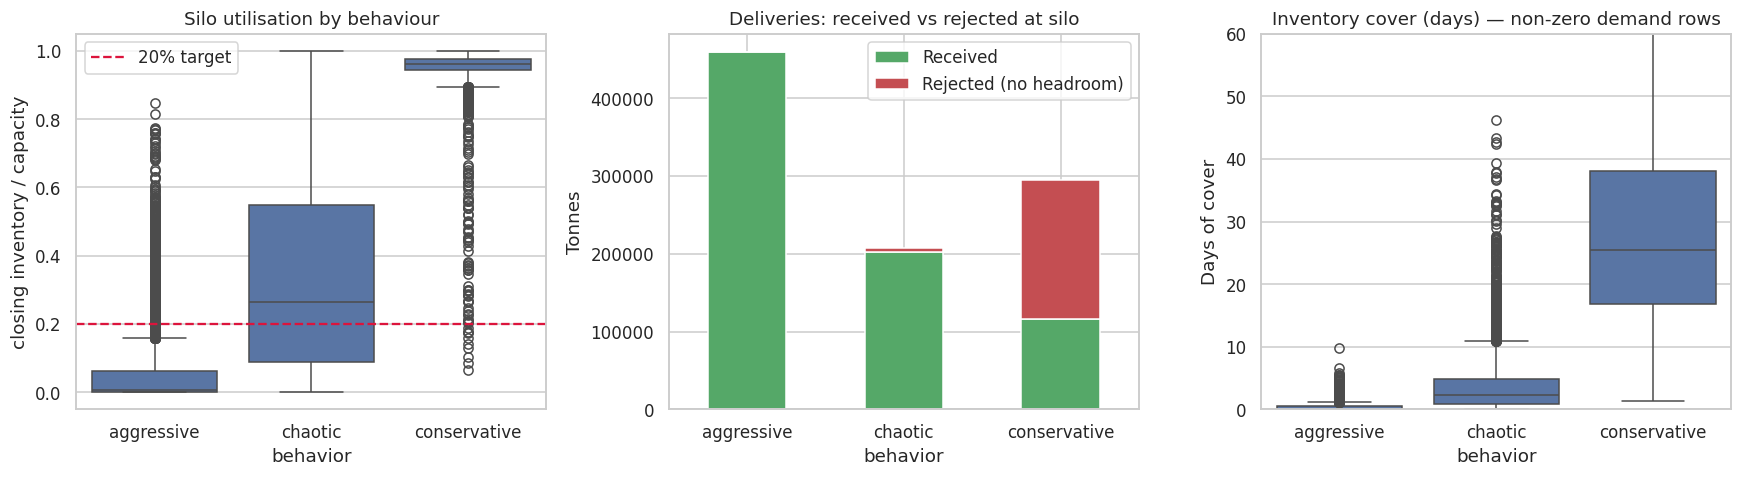

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(data=panel, x="behavior", y="silo_utilisation", ax=axes[0],
            order=["aggressive", "chaotic", "conservative"])
axes[0].set_title("Silo utilisation by behaviour")
axes[0].set_ylabel("closing inventory / capacity")
axes[0].axhline(0.20, color="crimson", linestyle="--", label="20% target")
axes[0].legend()

delivery_summary = panel.groupby("behavior")[["received_tonnes", "rejected_delivery_tonnes"]].sum()
delivery_summary.plot(kind="bar", stacked=True, ax=axes[1], color=["#55a868", "#c44e52"])
axes[1].set_title("Deliveries: received vs rejected at silo")
axes[1].set_ylabel("Tonnes")
axes[1].legend(["Received", "Rejected (no headroom)"])

sns.boxplot(data=panel.dropna(subset=["cover_days"]), x="behavior", y="cover_days",
            ax=axes[2], order=["aggressive", "chaotic", "conservative"])
axes[2].set_title("Inventory cover (days) — non-zero demand rows")
axes[2].set_ylabel("Days of cover")
axes[2].set_ylim(0, 60)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_fig("inventory_state")
plt.show()

In [28]:
# ==========================================
# Baseline against the Phase 4 business targets
# ==========================================
pour_days = panel[panel["planned_pour_tonnes"] > 0]
readiness = 1 - pour_days["was_constrained"].mean()

baseline_targets = pd.DataFrame({
    "metric": [
        "Pour readiness (unconstrained share of planned-pour days)",
        "Mean silo utilisation",
        "Rejected deliveries as % of offered",
        "Demand fill rate (tonnage)",
    ],
    "current (as-is)": [
        f"{100 * readiness:.1f}%",
        f"{100 * panel['silo_utilisation'].mean():.1f}%",
        f"{100 * panel['rejected_delivery_tonnes'].sum() / panel['deliveries_tonnes'].sum():.1f}%",
        f"{100 * panel['consumed_tonnes'].sum() / panel['planned_pour_tonnes'].sum():.1f}%",
    ],
    "Phase 4 target": ["98%", "<= 20% headroom waste", "-30% write-off", "-"],
})
display(baseline_targets)

print("These are the numbers notebook 05 must beat. Record them now, before any")
print("policy is designed, so the improvement claim in the final report is honest.")

,metric,current (as-is),Phase 4 target
0,Pour readiness (unconstrained share of planned...,56.3%,98%
1,Mean silo utilisation,38.7%,<= 20% headroom waste
2,Rejected deliveries as % of offered,19.2%,-30% write-off
3,Demand fill rate (tonnage),77.3%,-


These are the numbers notebook 05 must beat. Record them now, before any
policy is designed, so the improvement claim in the final report is honest.


## 12 — Correlation, split by forecast-time availability

A correlation heatmap over every numeric column is actively misleading here: it
mixes the target's own aliases, same-day outcomes, and genuine predictors on one
colour scale. The strongest cells end up being the ones that must never be
features. This section separates them explicitly.

In [29]:
# ==========================================
# 12a. Circular and contemporaneous columns — documented, then excluded
# ==========================================
target = panel["consumed_tonnes"]
leak_cols = [c for c in OUTCOME_COLS if c != "consumed_tonnes"]
excluded = (
    panel[leak_cols].select_dtypes("number").corrwith(target)
    .sort_values(key=abs, ascending=False)
    .to_frame("corr with consumed_tonnes")
)
excluded["why excluded"] = [
    {
        "y": "alias of the target",
        "served_tonnes": "the target after ledger repair",
        "unmet_tonnes": "planned - consumed, contains the target",
        "was_constrained": "realised on day t",
        "induced_shortfall": "realised on day t",
        "received_tonnes": "realised on day t",
        "rejected_delivery_tonnes": "realised on day t",
        "closing_inventory_tonnes": "end-of-day state, depends on the target",
        "silo_utilisation": "closing inventory / capacity",
        "cover_days": "null exactly when the target is zero (see section 2)",
    }.get(c, "outcome of day t")
    for c in excluded.index
]
display(excluded.round(3))
print("None of the above may be used as a feature at its own timestamp.")
print("Lagged versions (shift 1 within site) are legitimate — see notebook 03.")

,corr with consumed_tonnes,why excluded
y,1.000,alias of the target
served_tonnes,0.994,the target after ledger repair
cover_days,-0.605,null exactly when the target is zero (see sect...
silo_utilisation,-0.486,closing inventory / capacity
received_tonnes,0.451,realised on day t
closing_inventory_tonnes,-0.429,"end-of-day state, depends on the target"
rejected_delivery_tonnes,-0.362,realised on day t
unmet_tonnes,-0.132,"planned - consumed, contains the target"
induced_shortfall,0.124,realised on day t
was_constrained,0.063,realised on day t


None of the above may be used as a feature at its own timestamp.
Lagged versions (shift 1 within site) are legitimate — see notebook 03.


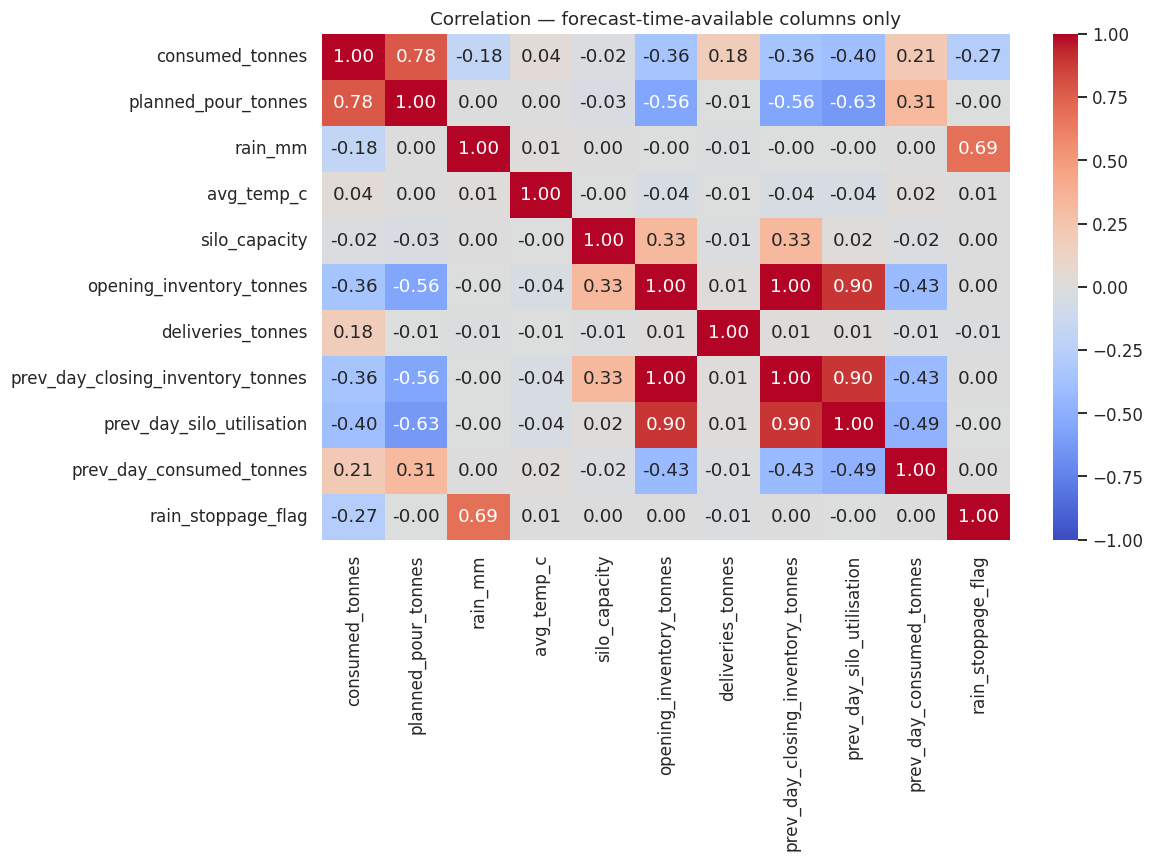

,corr with target
planned_pour_tonnes,0.781
prev_day_silo_utilisation,-0.397
prev_day_closing_inventory_tonnes,-0.359
opening_inventory_tonnes,-0.359
rain_stoppage_flag,-0.268
prev_day_consumed_tonnes,0.215
rain_mm,-0.180
deliveries_tonnes,0.177
avg_temp_c,0.035
silo_capacity,-0.021


In [30]:
# ==========================================
# 12b. Forecast-time-safe correlations
# ==========================================
panel_sorted = panel.sort_values(["site_id", "date"])
lagged_state = (
    panel_sorted.groupby("site_id")[
        ["closing_inventory_tonnes", "silo_utilisation", "consumed_tonnes"]
    ]
    .shift(1)
    .add_prefix("prev_day_")
)

safe_frame = pd.concat(
    [
        panel_sorted[[
            "consumed_tonnes",
            "planned_pour_tonnes",
            "rain_mm",
            "avg_temp_c",
            "silo_capacity",
            "opening_inventory_tonnes",
            "deliveries_tonnes",
        ]],
        lagged_state,
        (panel_sorted["rain_mm"] > RAIN_STOPPAGE_MM).astype(int).rename("rain_stoppage_flag"),
    ],
    axis=1,
)

plt.figure(figsize=(11, 8))
sns.heatmap(safe_frame.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1)
plt.title("Correlation — forecast-time-available columns only")
plt.tight_layout()
save_fig("correlation_safe")
plt.show()

display(
    safe_frame.corr()["consumed_tonnes"].drop("consumed_tonnes")
    .sort_values(key=abs, ascending=False).round(3).to_frame("corr with target")
)

In [31]:
# ==========================================
# 12c. A pooled correlation is not evidence of temporal memory
# ==========================================
# prev_day_consumed correlates at +0.215 in the table above, which looks like it
# contradicts section 7. It does not: pooling across sites lets a *cross-sectional*
# effect masquerade as an autocorrelation. Demean within site to separate them.
prev_day = panel_sorted.groupby("site_id")["consumed_tonnes"].shift(1)
site_mean_c = panel_sorted.groupby("site_id")["consumed_tonnes"].transform("mean")

pooled = prev_day.corr(panel_sorted["consumed_tonnes"])
within = (prev_day - site_mean_c).corr(panel_sorted["consumed_tonnes"] - site_mean_c)

print(f"corr(prev-day consumption, consumption), pooled across sites : {pooled:+.3f}")
print(f"the same correlation, demeaned WITHIN each site              : {within:+.3f}")
print()
print("The pooled figure is a site fixed effect: busy sites are busy on")
print("consecutive days because they are busy sites, not because yesterday")
print("informs today. A lag-1 feature here would encode site identity, which")
print("`behavior` already supplies more cheaply and without the warm-up cost.")

corr(prev-day consumption, consumption), pooled across sites : +0.215
the same correlation, demeaned WITHIN each site              : -0.021

The pooled figure is a site fixed effect: busy sites are busy on
consecutive days because they are busy sites, not because yesterday
informs today. A lag-1 feature here would encode site identity, which
`behavior` already supplies more cheaply and without the warm-up cost.


**Finding — one dominant predictor, one engineered flag, and very little else.**

Among columns available at forecast time, `planned_pour_tonnes` (r = +0.78) is
the only strong signal. The engineered `rain_stoppage_flag` reaches r = −0.27 —
modest as a linear statistic precisely because its effect is a switch on 4.9% of
rows rather than a gradient across all of them, which is why §13 evaluates it by
WAPE instead. `opening_inventory_tonnes` (−0.36) matters only through the
censoring mechanism, not as a demand driver.

**The lag-1 trap.** `prev_day_consumed_tonnes` shows r = +0.215 pooled, which
appears to contradict §7. Demeaned within site it is **−0.021**. The pooled
figure is entirely a site fixed effect — a lag feature here would encode *which
site this is*, not *what happened yesterday*, and `behavior` already does that
with no warm-up rows and no leakage surface. This is the single most likely way
for a lag block to look useful in cross-validation and add nothing in production.

The excluded table is the important half of this section: `cover_days`
(r = −0.61), `silo_utilisation` (−0.49) and `closing_inventory_tonnes` (−0.43)
are the third, fourth and fifth strongest correlations in a naive all-numeric
matrix, and all three are **consequences** of the day's consumption. A model
given them scores beautifully in validation and fails in production. This table
is the audit trail for WORKFLOW §2.6 — carry it into notebook 03.

## 13 — What actually generates the target

§5, §9 and §10 each isolated one mechanism. Composed, they are not three
features — they are the data-generating process. This section tests that directly.

In [32]:
# ==========================================
# A three-term rule with NO fitted parameters
# ==========================================
def wape(actual, forecast):
    return np.abs(actual - forecast).sum() / np.abs(actual).sum()

demand_gate = panel["planned_pour_tonnes"] * (panel["rain_mm"] <= RAIN_STOPPAGE_MM)
stock_available = panel["opening_inventory_tonnes"] + panel["deliveries_tonnes"]
rule = np.minimum(demand_gate, stock_available)

actual = panel["consumed_tonnes"]
r2 = 1 - ((actual - rule) ** 2).sum() / ((actual - actual.mean()) ** 2).sum()

print("RULE:  consumed = min( planned_pour x [rain <= 15mm] , opening_inventory + deliveries )")
print(f"  exact match (within 1e-6) : {np.isclose(rule, actual, atol=1e-6).mean():.1%} of rows")
print(f"  WAPE                      : {wape(actual, rule):.4f}")
print(f"  R-squared                 : {r2:.4f}")
print("  fitted parameters         : 0")

RULE:  consumed = min( planned_pour x [rain <= 15mm] , opening_inventory + deliveries )
  exact match (within 1e-6) : 83.9% of rows
  WAPE                      : 0.0426
  R-squared                 : 0.9600
  fitted parameters         : 0


,WAPE,RMSE,bias (t)
forecast,,,
Global mean,0.605,16.846,-0.000
Per-site mean,0.468,14.777,-0.000
Planned pour (WORKFLOW 3.2 benchmark),0.294,14.123,6.977
Planned pour x rain gate,0.247,11.833,5.460
"Planned x rain gate, capped by stock",0.043,3.369,0.388


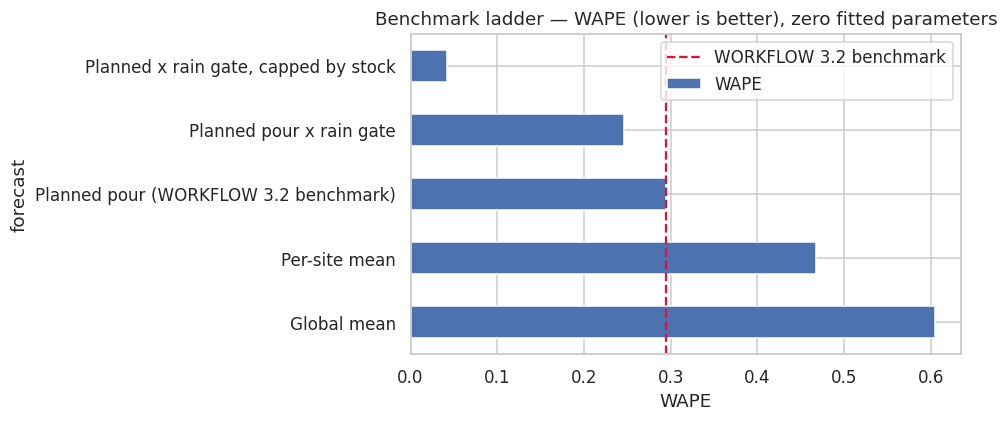

In [33]:
# ==========================================
# Benchmark ladder — the bar Phase 3 has to clear
# ==========================================
site_mean = panel.groupby("site_id")["consumed_tonnes"].transform("mean")

benchmarks = pd.DataFrame([
    ("Global mean", np.full(len(panel), actual.mean())),
    ("Per-site mean", site_mean),
    ("Planned pour (WORKFLOW 3.2 benchmark)", panel["planned_pour_tonnes"]),
    ("Planned pour x rain gate", demand_gate),
    ("Planned x rain gate, capped by stock", rule),
], columns=["forecast", "values"])

benchmarks["WAPE"] = [wape(actual, v) for v in benchmarks["values"]]
benchmarks["RMSE"] = [np.sqrt(((actual - v) ** 2).mean()) for v in benchmarks["values"]]
benchmarks["bias (t)"] = [(v - actual).mean() for v in benchmarks["values"]]
ladder = benchmarks.drop(columns="values").set_index("forecast").round(4)
display(ladder)

plt.figure(figsize=(9, 4))
ladder["WAPE"].plot(kind="barh", color="#4c72b0")
plt.axvline(ladder.loc["Planned pour (WORKFLOW 3.2 benchmark)", "WAPE"],
            color="crimson", linestyle="--", label="WORKFLOW 3.2 benchmark")
plt.title("Benchmark ladder — WAPE (lower is better), zero fitted parameters")
plt.xlabel("WAPE")
plt.legend()
plt.tight_layout()
save_fig("benchmark_ladder")
plt.show()

**Finding — the target is very nearly deterministic.**

| forecast rule | WAPE | fitted parameters |
|---|---|---|
| Global mean | 60.5% | 1 |
| Per-site mean | 46.8% | 30 |
| **Planned pour** (the WORKFLOW §3.2 benchmark) | **29.4%** | 0 |
| Planned pour × rain gate | 24.7% | 0 |
| **Planned × rain gate, capped by available stock** | **4.3%** | **0** |

`consumed = min(planned_pour × [rain ≤ 15 mm], opening_inventory + deliveries)`
reproduces the target exactly on 83.9% of rows, with R² = 0.96 and WAPE 4.3%,
without fitting anything. The residual concentrates on constrained rows (87% of
the misses are `was_constrained == 1`), where the interaction with the ledger is
imperfect.

**This reframes the project, and it should be said plainly in the final report.**

1. **There is very little left for a learned model to add on this data.** Phase 3
   must be honest about the ceiling: any ML model should be benchmarked against
   this rule, not against the naive mean. Beating 4.3% WAPE is the real bar. A
   LightGBM reporting 12% WAPE would be a *worse* result dressed up as a good one.
2. **The forecasting problem is really a scheduling problem.** All the signal is
   in `planned_pour_tonnes`, which is set administratively. The genuinely useful
   forecasting question is *"what will the planned pour be 8 weeks out"*, plus a
   probabilistic rain gate. Recommend reframing Phase 3 around forecasting
   planned pour and treating the rest as deterministic composition.
3. **Forecasting and inventory simulation are the same model.** The stock term
   in the rule is unknown beyond h = 1 — it is an *output* of the Phase 4
   simulation. So the 8-week forecast must be produced by rolling the demand
   forecast and the inventory projection forward together, not by running
   notebook 04 and then notebook 05 in sequence. This is an architectural
   decision that needs making now, before `src/models/` is written.
4. **The value story is inventory, not accuracy** — which WORKFLOW §5 already
   flagged as the fallback. §10 shows it is the main story: aggressive sites lose
   195,289 tonnes of planned work to an ordering policy, not to demand
   uncertainty. Fixing that is worth far more than a better point forecast.

## 14 — Findings, and the decisions they close

Every row below belongs in `REPORTS/decisions.md`. The right-hand column is the
recommendation this notebook supports.

In [34]:
findings = pd.DataFrame([
    ("2.1", "Site heterogeneity",
     "site 23.1% of variance, behaviour 23.0%, region 1.5%, cement_type 0.0%",
     "ONE global pooled model with `behavior` as a categorical. Not 30 per-site models."),
    ("2.2", "Temporal memory",
     "site-level autocorr <= |0.02| at lags 1/7/14/28; no site exceeds |r|=0.10; ACF/PACF inside the white-noise band",
     "CUT the lag and rolling-stat feature block. Fit SARIMAX once as a documented baseline only."),
    ("1.3(d)", "Calendar seasonality",
     "fixed weekday effect explains 0.0% of variance, month 0.1%; STL seasonal strength only 0.28",
     "Drop calendar features. No seasonal ARIMA terms."),
    ("2.3", "Weather",
     "hard threshold at 15.0mm: consumption 24.7t -> 4.0t, zero-days 9.3% -> 67.9%; r = +0.005 below the threshold",
     "Add binary `rain_stoppage`. Drop linear rain_mm and avg_temp_c. Model it as P(rain<=15) at long horizons."),
    ("2.4", "Censored target",
     "39.7% of rows constrained; aggressive sites 65.0% constrained, 195,289t unmet, 5% utilisation vs conservative 14.3% / 3,476t / 95%",
     "TARGET = planned_pour_tonnes. Report accuracy on consumed_tonnes plus fill rate."),
    ("2.6", "Leakage",
     "cover_days is null exactly when y==0; silo_utilisation / closing_inventory / unmet are day-t outcomes",
     "Use section 3 availability table as the allow-list. Lagged state only, shift 1 within site."),
    ("1.3(e)", "Metric set",
     "12.2% zero rows, structurally explained (75% no pour scheduled)",
     "WAPE + MASE primary. MAPE at weekly grain only. Add a hurdle/two-stage structure."),
    ("3.2", "Benchmark",
     "min(planned x rain gate, stock) gives WAPE 4.3%, R2 0.96, zero fitted parameters",
     "This rule, not the naive mean, is the bar for Phase 3. Reframe around forecasting planned pour."),
    ("4.x", "Architecture",
     "the stock term is an output of the inventory simulation, unknown beyond h=1",
     "Roll demand forecast and inventory projection forward JOINTLY. Decide before src/models/ is written."),
], columns=["WORKFLOW ref", "finding", "evidence", "recommended decision"])

pd.set_option("display.max_colwidth", None)
display(findings.set_index("WORKFLOW ref"))

,finding,evidence,recommended decision
WORKFLOW ref,,,
2.1,Site heterogeneity,"site 23.1% of variance, behaviour 23.0%, region 1.5%, cement_type 0.0%",ONE global pooled model with `behavior` as a categorical. Not 30 per-site models.
2.2,Temporal memory,site-level autocorr <= |0.02| at lags 1/7/14/28; no site exceeds |r|=0.10; ACF/PACF inside the white-noise band,CUT the lag and rolling-stat feature block. Fit SARIMAX once as a documented baseline only.
1.3(d),Calendar seasonality,"fixed weekday effect explains 0.0% of variance, month 0.1%; STL seasonal strength only 0.28",Drop calendar features. No seasonal ARIMA terms.
2.3,Weather,"hard threshold at 15.0mm: consumption 24.7t -> 4.0t, zero-days 9.3% -> 67.9%; r = +0.005 below the threshold",Add binary `rain_stoppage`. Drop linear rain_mm and avg_temp_c. Model it as P(rain<=15) at long horizons.
2.4,Censored target,"39.7% of rows constrained; aggressive sites 65.0% constrained, 195,289t unmet, 5% utilisation vs conservative 14.3% / 3,476t / 95%",TARGET = planned_pour_tonnes. Report accuracy on consumed_tonnes plus fill rate.
2.6,Leakage,cover_days is null exactly when y==0; silo_utilisation / closing_inventory / unmet are day-t outcomes,"Use section 3 availability table as the allow-list. Lagged state only, shift 1 within site."
1.3(e),Metric set,"12.2% zero rows, structurally explained (75% no pour scheduled)",WAPE + MASE primary. MAPE at weekly grain only. Add a hurdle/two-stage structure.
3.2,Benchmark,"min(planned x rain gate, stock) gives WAPE 4.3%, R2 0.96, zero fitted parameters","This rule, not the naive mean, is the bar for Phase 3. Reframe around forecasting planned pour."
4.x,Architecture,"the stock term is an output of the inventory simulation, unknown beyond h=1",Roll demand forecast and inventory projection forward JOINTLY. Decide before src/models/ is written.


### Exit criteria for Phase 2 (EDA half)

- [x] §2.1 answered — global model, `behavior` as the heterogeneity carrier
- [x] §2.2 answered — no memory; lag block cut
- [x] §2.3 answered — 15 mm threshold, flag specified
- [x] §2.4 answered — censoring quantified by behaviour and inventory position; target decision made
- [x] Leakage allow-list drafted (§3, §12) — to be enforced in `03_Feature_Engineering.ipynb`
- [x] Benchmark ladder recorded (§13) — Phase 3 has a real bar to clear
- [ ] Findings transcribed into `REPORTS/decisions.md` and signed off by both collaborators
- [ ] Contract-1 feature matrix emitted to `DATA/processed/` — notebook 03

**Handover to `03_Feature_Engineering.ipynb`.** The feature set this notebook
supports is short by design:

`planned_pour_tonnes`, `rain_stoppage` (rain_mm > 15), `behavior`,
`silo_capacity`, lagged inventory state (shift 1), `cement_type` (for inventory
allocation, not prediction). No target lags, no rolling statistics, no calendar
terms, no raw same-day inventory. Every omission above has a numbered
justification in this notebook.